# Task 3: Predicting Gender and Occasion from Fashion Images

Given a photograph of a fashion item, predict two attributes: the **gender** it is intended for
and the **occasion** (`usage`) it suits.

## Approach

A convolutional neural network, trained from scratch on the catalogue at 60×80 resolution, the
size the images are supplied at. The same pipeline was also trained at 120×160, with a fifth
convolutional block and three times the parameters, and returned every test metric within 0.2 of
the figures below; the extra pixels are not what this problem was short of. The network follows
the standard four-stage structure:

```
convolution  ->  non-linearity  ->  pooling  ->  fully-connected classifier
```

The first three stages extract features; the fourth turns those features into class scores. All
four are trained together by a single optimiser, so the convolutional filters are shaped by the
classification objective rather than by any separate criterion.

Because there are two attributes to predict, the network **branches early**: the first two
convolutional blocks are shared, then each attribute gets its own convolutional pathway and its
own classifier. The rationale is set out in Part 3.

## Structure of this notebook

| Part | Contents |
|---|---|
| 1 | Data, labels, baselines, and the train/validation/test split |
| 2 | The four stages, and the reasoning behind every design choice |
| 3 | Architecture selection, and the network definition |
| 4 | **Training the model** |
| 5 | Addressing class imbalance |
| 6 | Final model, specification, and test results |

Parts 2 and 3 are analysis; Part 4 is where the model is actually built. Part 5 is a controlled
experiment that changes one factor at a time.

## Evaluation

`usage` is 77% `Casual`, so accuracy alone is misleading, since a constant predictor reaches that
figure without learning anything. **Macro-F1** is the primary metric because it weights every
class equally. Exact-match accuracy, where both attributes must be correct, is reported as the
product-level measure. All comparisons are judged against the sampling error of the validation
set, computed in Part 6.

## Part 1: Data

In [1]:
# ============================================
# CELL 1 - Environment
# ============================================

import os
import json
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# VS Code runs a notebook from its own directory, so the working directory here is
# `notebooks/` and the project root is one level above it. Anchoring every path on
# PROJECT_DIR rather than writing it relative to the file means the notebook does not
# depend on that: a launcher that starts at the project root instead would only need
# this pair of lines changed.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
PROCESSED_DIR = PROJECT_DIR / "A2_FashionDataset" / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task3"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Resolution. This pipeline was also trained at 120x160 - four times the pixels, a fifth
# convolutional block, three times the parameters - and every test metric landed within
# 0.2 of the figures this notebook reports. The extra resolution was not what the model
# was short of. It runs at 60x80 and spends the saved time on repeated seeds instead,
# which is what the comparison in Part 6 was short of.
CONFIG = {
    "image_width": 60, "image_height": 80, "channels": 3,
    "targets": ["gender", "usage"],
    "batch_size": 128,
    "max_epochs": 50,                 # a ceiling, not a target: early stopping ends
    "early_stopping_patience": 8,     # each run when it stops improving
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "num_workers": 0,                 # 0 required on Windows notebooks
    "mixed_precision": True,          # half precision where it is numerically safe
}
# The source folder follows the resolution: the 120x160 export for the high-resolution
# run, the catalogue images as supplied otherwise. `image_path` in the metadata points at
# the originals either way, so paths are rebuilt from the id rather than read from it.
IMAGE_DIR = (PROCESSED_DIR / "images_train_120x160" if CONFIG["image_height"] > 80
             else PROJECT_DIR / "A2_FashionDataset" / "FashionDataset" / "train"
             / "images_train")

IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)
INPUT_SHAPE = (3, CONFIG["image_height"], CONFIG["image_width"])
print(json.dumps(CONFIG, indent=2))

PyTorch: 2.11.0+cu128 | device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
{
  "image_width": 60,
  "image_height": 80,
  "channels": 3,
  "targets": [
    "gender",
    "usage"
  ],
  "batch_size": 128,
  "max_epochs": 50,
  "early_stopping_patience": 8,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "num_workers": 0,
  "mixed_precision": true
}


### Labels

`gender` has five values and needs no adjustment. `usage` has eight, but four of them are
vanishingly rare: `Smart Casual` (55 items), `Travel` (25), `Party` (13) and `Home` (1). Classes
that small cannot be learned, and cannot be stratified across a split.

Each is merged into its nearest surviving class based on what the items actually are rather than
on the label text:

* `Smart Casual`: dominated by watches, shirts and shoes, all everyday items → **Casual**
* `Travel`: every row is a bag (backpacks, rucksacks, duffels) → **Casual**
* `Party`: dresses, clutches and heels, all occasion wear → **Formal**
* `Home`: a single cushion cover, not a fashion item → **removed**

Rows with a missing `usage` label are dropped rather than imputed: assigning them the majority
class would insert confidently wrong labels into the class the model is already biased towards.

In [2]:
# ============================================
# CELL 2 - Labels
# ============================================

data = pd.read_csv(PROCESSED_DIR / "train_metadata_120x160_supervised.csv")
print("rows loaded:", len(data))

# Hashing the images at full resolution shows that 1,399 of them are byte-identical to
# another catalogue entry. In 41 of those pairs the two entries disagree about gender or
# usage, so a single photograph carries two different answers and neither row can be used
# for supervised training. They are marked use_for_supervised=False when the metadata is
# built, and are removed here rather than being allowed to contradict each other.
data = data[data["use_for_supervised"]].copy()
print("rows carrying a consistent label:", len(data))

model_df = data[data["usage"].notna() & data["gender"].notna()].copy()
print(f"dropped {len(data) - len(model_df)} rows with a missing target")

USAGE_MERGE = {"Smart Casual": "Casual", "Travel": "Casual", "Party": "Formal"}
model_df = model_df[model_df["usage"] != "Home"].copy()
model_df["usage_label"] = model_df["usage"].replace(USAGE_MERGE)
model_df["gender_label"] = model_df["gender"]

from sklearn.preprocessing import LabelEncoder

encoders, class_names = {}, {}
for target in CONFIG["targets"]:
    encoder = LabelEncoder()
    model_df[target + "_y"] = encoder.fit_transform(model_df[target + "_label"].astype(str))
    encoders[target] = encoder
    class_names[target] = list(encoder.classes_)

NUM_CLASSES = {t: len(encoders[t].classes_) for t in CONFIG["targets"]}
model_df = model_df.reset_index(drop=True)

for target in CONFIG["targets"]:
    counts = model_df[target + "_label"].value_counts()
    print(f"\n{target}: {len(counts)} classes")
    display(pd.DataFrame({"count": counts,
                          "share %": (counts / len(model_df) * 100).round(1)}))

rows loaded: 38612
rows carrying a consistent label: 38571
dropped 72 rows with a missing target

gender: 5 classes


,count,share %
gender_label,,
Men,20865,54.2
Women,14122,36.7
Unisex,2058,5.3
Boys,809,2.1
Girls,644,1.7



usage: 4 classes


,count,share %
usage_label,,
Casual,29687,77.1
Sports,3935,10.2
Ethnic,2567,6.7
Formal,2309,6.0


In [3]:
# ============================================
# CELL 3 - Baselines
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

BASELINE = {}
for target in CONFIG["targets"]:
    y = model_df[target + "_y"].values
    dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y), 1)), y)
    pred = dummy.predict(np.zeros((len(y), 1)))
    BASELINE[target] = {"accuracy": accuracy_score(y, pred) * 100,
                        "macro_f1": f1_score(y, pred, average="macro", zero_division=0) * 100}
    print(f"{target:8s} majority class -> accuracy {BASELINE[target]['accuracy']:5.2f}%, "
          f"macro-F1 {BASELINE[target]['macro_f1']:5.2f}")

print("\nThe gap between these two columns is why macro-F1 is the primary metric:")
print("a constant predictor reaches 77% accuracy on usage but only 22 macro-F1.")

gender   majority class -> accuracy 54.20%, macro-F1 14.06
usage    majority class -> accuracy 77.11%, macro-F1 21.77

The gap between these two columns is why macro-F1 is the primary metric:
a constant predictor reaches 77% accuracy on usage but only 22 macro-F1.


### Splitting

The catalogue contains many near-identical photographs of the same product: over 15,000 rows
share a `productDisplayName` with another row. A random split would place copies of one item on
both sides, so the model could score well by recognising specific photographs.

Grouping on the product name is not sufficient on its own. Hashing the images at full resolution
finds 1,399 that are byte-identical to another catalogue entry, and 218 of those groups are filed
under **different** product names. `Idee Men Black Sunglasses` and `IDEE Men Black Sunglasses`
are one photograph under two entries. Grouping by name alone would leave 470 identical images on
both sides of the split, and at 60×80 nothing made them visible.

The split is therefore read from `splits_120x160.csv`, one assignment shared across the project.
It groups on `split_group`, which merges product names **and** duplicate-image families, and
stratifies on `articleType`. The resulting `gender` and `usage` proportions agree across the three
partitions to within half a percentage point, and holding out the same items as the other three
tasks lets the four models be compared on common ground.

Neither guard is exhaustive, and the partition is better described as free of duplicate images
than as free of leakage. Product **variants** photographed in the same frame, one shade of
compact powder against the next, are near-identical without being byte-identical, and they carry
different names, so the hash and the grouping both miss them. At least 1.5% of the held-out rows
have such a twin in the training partition. The effect on the reported scores is small and runs in
both directions: gender accuracy on those rows is 98.8% against 89.9% elsewhere, lifting the
headline gender figure by roughly 0.13, while usage accuracy on them is *lower* and pulls that
figure down by roughly 0.20. Both movements sit well inside the threshold established in Part 6.


In [27]:
# ============================================
# CELL 4 - Train / validation / test split
# ============================================

# The split is read rather than recomputed. `splits_120x160.csv` is one assignment
# shared by every task in the project, grouped on `split_group` and stratified on
# articleType. Two properties of it matter here.
#
# First, `split_group` merges more than a product name does. 218 groups of identical
# photographs are filed under different product names - "Idee Men Black Sunglasses"
# and "IDEE Men Black Sunglasses" are the same image - so grouping on the name alone
# would leave 470 identical photographs on both sides of the split. Nothing at 60x80
# revealed them; a hash of the full-resolution image does.
#
# Second, one shared assignment means this task holds out the same items as the other
# three, so the four models are measured on common ground.

splits = pd.read_csv(PROCESSED_DIR / "splits_120x160.csv")
model_df = (model_df.drop(columns=["split"], errors="ignore")
            .merge(splits, on="id", how="inner", validate="one_to_one"))

train_df = model_df[model_df["split"] == "train"].copy()
val_df = model_df[model_df["split"] == "val"].copy()
test_df = model_df[model_df["split"] == "test"].copy()

for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name:11s} {len(part):>6,}")

for a, b, label in [(train_df, val_df, "train/val"), (train_df, test_df, "train/test"),
                    (val_df, test_df, "val/test")]:
    assert not set(a["split_group"]) & set(b["split_group"]), f"group leaked across {label}"
    assert not set(a["id"]) & set(b["id"]), f"id leaked across {label}"
print("\nNo product, and no byte-identical photograph, appears in more than one "
      "partition.")
# Byte-identical is not the same as unique. Product variants photographed in the same
# frame - one shade of a compact powder beside another - differ by a fraction of a grey
# level and carry different product names, so neither the hash nor the name grouping
# separates them. These partitions are duplicate-free, which is the weaker of the two
# claims; the markdown above states what that leaves behind.

comparison = pd.DataFrame({
    "train %": train_df["usage_label"].value_counts(normalize=True) * 100,
    "val %": val_df["usage_label"].value_counts(normalize=True) * 100,
    "test %": test_df["usage_label"].value_counts(normalize=True) * 100}).round(1)
display(comparison)


train       27,497
validation   5,500
test         5,501

No product, and no byte-identical photograph, appears in more than one partition.


,train %,val %,test %
usage_label,,,
Casual,77.1,76.9,77.3
Sports,10.2,10.2,10.3
Ethnic,6.7,6.7,6.3
Formal,5.9,6.2,6.1


In [28]:
# ============================================
# CELL 5 - Image cache and data loaders
# ============================================

CACHE_X = PROCESSED_DIR / f"task3cnn_cache_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"
CACHE_IDS = CACHE_X.with_name(CACHE_X.stem + "_ids.npy")


def load_image_array(path, size=IMAGE_SIZE_PIL):
    with Image.open(path) as img:
        return np.asarray(img.convert("RGB").resize(size, Image.BILINEAR), dtype=np.uint8)


ids = model_df["id"].to_numpy()
cached_ids = np.load(CACHE_IDS) if (CACHE_X.exists() and CACHE_IDS.exists()) else None

# A cache is reusable whenever it holds every id this run needs, not only when it matches
# the frame row for row: rows are addressed through `position_of` below rather than assumed
# to line up. The label policy has removed rows since some of these caches were written,
# and rebuilding 38,000 images to drop a few dozen of them would cost ten minutes for
# nothing.
if cached_ids is not None and set(ids.tolist()) <= set(cached_ids.tolist()):
    IMAGES = np.load(CACHE_X, mmap_mode="r")
    cache_ids = cached_ids
    print(f"image cache loaded: {IMAGES.shape} "
          f"({len(ids):,} of {len(cache_ids):,} cached rows used)")
else:
    print("building image cache ...")
    IMAGES = np.lib.format.open_memmap(CACHE_X, mode="w+", dtype=np.uint8,
                                       shape=(len(model_df),) + IMAGE_SHAPE)
    # `image_path` in the metadata points at the catalogue images whatever the resolution,
    # so the path is rebuilt from the id against IMAGE_DIR instead of read from the column.
    for position, image_id in enumerate(model_df["id"]):
        IMAGES[position] = load_image_array(IMAGE_DIR / f"{image_id}.jpg")
        if (position + 1) % 10000 == 0:
            print(f"  {position + 1:,}/{len(model_df):,}")
    IMAGES.flush(); np.save(CACHE_IDS, ids)
    cache_ids = ids

position_of = {int(image_id): position for position, image_id in enumerate(cache_ids)}
for part in (train_df, val_df, test_df):
    part["pos"] = part["id"].map(position_of).astype(int)

# Normalisation statistics come from the training split only; using the whole
# dataset would leak information from validation and test into training.
# The sample is accumulated in blocks: at this resolution, converting 4,000 images to
# float in one array would allocate close to a gigabyte to produce three numbers.
sample_positions = np.sort(train_df["pos"].sample(
    min(4000, len(train_df)), random_state=RANDOM_STATE).to_numpy())
pixels, channel_sum, channel_square_sum = 0, np.zeros(3), np.zeros(3)
for start in range(0, len(sample_positions), 500):
    block = np.asarray(IMAGES[sample_positions[start:start + 500]],
                       dtype=np.float32).reshape(-1, 3) / 255.0
    channel_sum += block.sum(axis=0)
    channel_square_sum += np.square(block).sum(axis=0)
    pixels += len(block)
CHANNEL_MEAN = (channel_sum / pixels).astype(np.float32)
CHANNEL_STD = np.sqrt(np.maximum(
    channel_square_sum / pixels - np.square(CHANNEL_MEAN), 0.0)).astype(np.float32)
MEAN_T = torch.tensor(CHANNEL_MEAN, dtype=torch.float32).view(3, 1, 1)
STD_T = torch.tensor(CHANNEL_STD, dtype=torch.float32).view(3, 1, 1)
print("channel mean:", CHANNEL_MEAN.round(4), "| std:", CHANNEL_STD.round(4))


class FashionDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.positions = frame["pos"].to_numpy()
        self.gender = frame["gender_y"].to_numpy()
        self.usage = frame["usage_y"].to_numpy()
        self.transform = transform

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        array = np.asarray(IMAGES[self.positions[index]], dtype=np.float32) / 255.0
        tensor = (torch.from_numpy(array.transpose(2, 0, 1)) - MEAN_T) / STD_T
        if self.transform is not None:
            tensor = self.transform(tensor)
        return tensor, int(self.gender[index]), int(self.usage[index])


def make_loader(frame, shuffle=False, transform=None, batch_sampler=None):
    dataset = FashionDataset(frame, transform)
    if batch_sampler is not None:
        return DataLoader(dataset, batch_sampler=batch_sampler,
                          num_workers=CONFIG["num_workers"],
                          pin_memory=(DEVICE.type == "cuda"))
    return DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=shuffle,
                      num_workers=CONFIG["num_workers"],
                      pin_memory=(DEVICE.type == "cuda"))


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df)
test_loader = make_loader(test_df)

images, gender, usage = next(iter(train_loader))
print("batch:", tuple(images.shape), "| classes:", NUM_CLASSES)

image cache loaded: (38539, 80, 60, 3) (38,498 of 38,539 cached rows used)
channel mean: [0.8516 0.8339 0.8279] | std: [0.2689 0.2811 0.2849]
batch: (128, 3, 80, 60) | classes: {'gender': 5, 'usage': 4}


## Part 2: The four stages and their configuration

### Stage 1: convolution

A small kernel slides across the image, computing a weighted sum at every position. The same
weights are reused everywhere, so a filter that responds to a collar responds to a collar
wherever it appears. This weight sharing is what separates a convolutional network from a dense
one: a fully connected layer on a 60×80×3 image would need 14,400 weights per neuron and would
have to learn "collar" separately for every location.

**Kernel size: 3×3 throughout.** Two stacked 3×3 layers see the same 5×5 neighbourhood as one
5×5 layer, but use 2 × 9C² weights instead of 25C², 28% fewer, and insert an extra
non-linearity between them. The saving compounds with depth. Larger kernels are only worth their
cost when the network is too shallow for the receptive field to accumulate, which is not the
case here.

**Filter counts: 32 → 64 → 128 → 256.** The count doubles each time pooling halves the spatial
size, keeping computation per block roughly constant while representations become more abstract.
Early layers need few filters because there are few distinct edge and colour patterns; later
layers need many because there are many distinct garment-level patterns.

### Stage 2: non-linearity

Without it, stacked convolutions collapse into a single linear transformation and depth achieves
nothing.

**ReLU.** `max(0, x)` passes gradient unchanged wherever a unit is active. `tanh` and `sigmoid`
both saturate: once inputs are large in either direction their gradient approaches zero, and in a
deep stack the multiplied gradients vanish before reaching early layers. ReLU also costs one
comparison rather than an exponential.

### Stage 3: pooling

Downsampling reduces computation and grants tolerance to small translations.

**Max pooling, 2×2.** Max keeps the strongest response in each window, which suits the question
these features answer: *is this pattern present?* Average pooling dilutes a strong local
response by mixing it with neighbouring background, and against a white backdrop a large
fraction of every window is background.

### Stage 4: fully-connected classifier

**Flatten, then two dense layers.** Flattening preserves *where* each feature fired, which
matters when an attribute depends on position: the difference between a garment's neckline and
its hem is partly vertical position in the frame. Global average pooling discards that, reducing
each channel to a single number.

The trade-off is parameters: the final 256×5×3 map flattens to 3,840 values, and the first dense
layer accounts for a large share of the network. Dropout is applied before each dense layer for
that reason.

### Regularisation

* **Batch normalisation** after every convolution, which stabilises training at higher learning rates
  and contributes mild regularisation.
* **Dropout 0.5** in the classifier, where most parameters live.
* **Weight decay 1e-4** on all weights.
* **Early stopping** on validation macro-F1, restoring the best epoch rather than the last.

Three of these choices (the activation, the pooling operator and the classifier head) are
settled on the reasoning above and taken as given. They are not varied experimentally here. The
controlled experiment this notebook does run is spent on class imbalance in Part 5, which is the
one property of the data that the design cannot be reasoned about in advance.

In [6]:
# ============================================
# CELL 6 - The four stages applied to a single image
# ============================================

demo = torch.zeros(1, *INPUT_SHAPE)
print("input                        ", tuple(demo.shape))

conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
x = conv(demo)
print("convolution 3->32, 3x3       ", tuple(x.shape),
      f"| {sum(p.numel() for p in conv.parameters()):,} weights")

x = F.relu(x)
print("non-linearity (ReLU)         ", tuple(x.shape), "  shape unchanged")

x = F.max_pool2d(x, 2)
print("pooling (max 2x2)            ", tuple(x.shape), "  spatial size halved")

flat = x.flatten(1)
print("flatten                      ", tuple(flat.shape))

head = nn.Linear(flat.shape[1], 5)
print("dense -> 5 class scores      ", tuple(head(flat).shape))

print("\nsoftmax converts those scores into probabilities:")
print(F.softmax(head(flat), dim=1).detach().numpy().round(3))
print("\nDuring training the network returns raw scores and nn.CrossEntropyLoss")
print("applies log-softmax internally, which is numerically more stable than")
print("applying softmax and then taking a logarithm.")


# --- the kernel-size argument, in numbers ---
channels = 64
print(f"\nParameters for one layer at {channels} channels:")
print(f"  single 5x5 : {25 * channels ** 2:>10,}")
print(f"  two   3x3  : {2 * 9 * channels ** 2:>10,}  (same receptive field, "
      f"{(1 - 2 * 9 / 25) * 100:.0f}% fewer)")

input                         (1, 3, 80, 60)
convolution 3->32, 3x3        (1, 32, 80, 60) | 896 weights
non-linearity (ReLU)          (1, 32, 80, 60)   shape unchanged
pooling (max 2x2)             (1, 32, 40, 30)   spatial size halved
flatten                       (1, 38400)
dense -> 5 class scores       (1, 5)

softmax converts those scores into probabilities:
[[0.211 0.202 0.19  0.191 0.206]]

During training the network returns raw scores and nn.CrossEntropyLoss
applies log-softmax internally, which is numerically more stable than
applying softmax and then taking a logarithm.

Parameters for one layer at 64 channels:
  single 5x5 :    102,400
  two   3x3  :     73,728  (same receptive field, 28% fewer)


In [7]:
# ============================================
# CELL 7 - Utilities
# ============================================

def flat_features(feature_extractor, input_shape=INPUT_SHAPE):
    """Measure the flattened size by running one dummy image through the stack.

    Measuring rather than hard-coding means the architecture can be resized
    without silently producing a shape mismatch.

    The probe tensor is placed on whichever device the module already occupies,
    so this works both at construction time (CPU) and after training (GPU).
    """
    try:
        device = next(feature_extractor.parameters()).device
    except StopIteration:                       # a module with no parameters
        device = torch.device("cpu")

    was_training = feature_extractor.training
    feature_extractor.eval()
    with torch.no_grad():
        output = feature_extractor(torch.zeros(1, *input_shape, device=device))
    feature_extractor.train(was_training)
    return int(np.prod(output.shape[1:])), tuple(output.shape[1:])


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Input resolution:", INPUT_SHAPE, "(channels, height, width)")

Input resolution: (3, 80, 60) (channels, height, width)


## Part 3: Architecture

### Choosing a reference design

Five landmark convolutional architectures were considered. The selection is driven by two
properties of this problem: a **moderate input** (60×80, against the 224×224 most of these
were designed for) and a **modest dataset** (27,000 training images, against ImageNet's 1.2
million).

| Architecture | Core idea | Fit for this problem |
|---|---|---|
| LeNet-5 (1998) | convolution + pooling + MLP, tanh, average pooling | Only two convolutional stages. Adequate for digits; too shallow to separate 5 gender and 4 occasion classes from garment appearance. |
| AlexNet (2012) | depth, ReLU, dropout, large stride-1 kernel | Its 11×11 stride-4 opening layer exists to shrink a 224×224 input quickly. At 60×80 it would discard most of the image before a single feature had been formed. |
| **VGG (2014)** | stacks of 3×3 kernels, doubling channel counts | **Selected.** The 3×3 stacking argument is independent of input size, the depth is appropriate for the data volume, and the uniform structure makes the design easy to reason about and adjust. |
| GoogLeNet (2014) | parallel 1×1/3×3/5×5 branches per module | Multi-scale branching pays off when object scale varies widely within the frame. Catalogue photography is consistently framed, so the additional complexity is not repaid. |
| ResNet (2015) | residual shortcuts | Shortcuts solve the degradation that appears beyond roughly 20 layers. This network is 8 convolutional layers deep, so there is no degradation for them to solve. |

VGG-style is therefore the base: four blocks, each two 3×3 convolutions followed by max pooling,
with channels doubling per block.

The block count follows from the input size rather than being fixed in advance, and the code
derives it: blocks are added until a branch leaves a map about five rows tall. Every block halves
both spatial dimensions, so four blocks reduce a 60×80 image to a 5×3 map, small enough that
flattening it costs 3,840 values per attribute. Three blocks would leave 10×7, and the first dense
layer alone would then hold about 2.3 million weights per attribute, and most of the network would sit
in the classifier. The same rule gives five blocks at 120×160, which is how that comparison was
run. Depth is the cheaper way to consume resolution, because a convolution reuses its
weights at every position and a dense layer does not.

### Multi-task structure: branching early

Two attributes must be predicted from one image. The network could share all convolutional
layers and split only at the classifier, but that makes every filter serve both objectives
simultaneously: the gradient reaching a filter is the sum of both tasks' gradients, so no filter
can specialise.

Branching early avoids that. The first two blocks are shared, because edges, colours and textures
are genuinely common to both questions. The deeper blocks are **separate convolutional pathways**,
so filters detecting formal tailoring receive gradient only from the occasion objective, and
filters detecting menswear cut only from the gender objective.

The cost is parameters: the deep layers exist twice. Since over 99% of the network sits after the
branch point, the model is close in size to two independent networks, since the shared trunk saves
compute on the cheap early layers, not on the expensive deep ones. The benefit is that feature
extraction stays tied to a single objective at the point where features become task-specific.

In [8]:
# ============================================
# CELL 8 - Network definition
# ============================================

def conv_block(in_channels, width, activation="relu", pooling="max"):
    """Two 3x3 convolutions, each followed by normalisation and a non-linearity,
    then a 2x2 downsample. The VGG pattern."""
    act = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}[activation]
    pool = {"max": nn.MaxPool2d, "avg": nn.AvgPool2d}[pooling]
    return [
        nn.Conv2d(in_channels, width, 3, padding=1, bias=False),
        nn.BatchNorm2d(width), act(),
        nn.Conv2d(width, width, 3, padding=1, bias=False),
        nn.BatchNorm2d(width), act(),
        pool(2),
    ]


def make_classifier(in_features, n_classes, hidden=256, dropout=0.5):
    """Flatten, then two dense layers with dropout before each."""
    return nn.Sequential(
        nn.Flatten(),
        nn.Dropout(dropout),
        nn.Linear(in_features, hidden),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(hidden, n_classes),
    )


SHARED_WIDTHS = (32, 64)


def branch_widths_for(image_height=None, widths=(128, 256, 512, 512)):
    """Blocks are added until a branch leaves a map about five rows tall.

    Every block halves both spatial dimensions, and the dense classifier is sized for the
    5x3 map that lands at the end of one. Deriving the count from the input rather than
    fixing it means a single definition serves either resolution - 60x80 takes four blocks
    in total, 120x160 takes five - and the flattened size stays the same instead of growing
    with the pixels. Stopping a block short would hand the head a 10x7 map and put several
    million parameters into two Linear layers, which is where overfitting starts. Depth is
    the cheaper way to consume resolution: a convolution reuses its weights at every
    position and a dense layer does not.
    """
    height = CONFIG["image_height"] if image_height is None else image_height
    blocks = max(len(SHARED_WIDTHS) + 1, int(round(np.log2(height / 5))))
    return tuple(widths[:blocks - len(SHARED_WIDTHS)])


BRANCH_WIDTHS = branch_widths_for()
print(f"input {CONFIG['image_height']}x{CONFIG['image_width']}: "
      f"{len(SHARED_WIDTHS)} shared + {len(BRANCH_WIDTHS)} branch blocks")


class EarlyBranchCNN(nn.Module):
    """Shared low-level blocks, then one convolutional pathway per attribute."""

    def __init__(self, num_classes, shared_widths=SHARED_WIDTHS,
                 branch_widths=BRANCH_WIDTHS, hidden=256, dropout=0.5,
                 activation="relu", pooling="max", head="flatten"):
        super().__init__()
        self.settings = {"shared_widths": list(shared_widths),
                         "branch_widths": list(branch_widths), "hidden": hidden,
                         "dropout": dropout, "activation": activation,
                         "pooling": pooling, "head": head}

        layers, channels = [], 3
        for width in shared_widths:
            layers += conv_block(channels, width, activation, pooling)
            channels = width
        self.shared = nn.Sequential(*layers)

        self.branches = nn.ModuleDict()
        self.heads = nn.ModuleDict()
        for target, n_classes in num_classes.items():
            branch_layers, branch_channels = [], channels
            for width in branch_widths:
                branch_layers += conv_block(branch_channels, width, activation, pooling)
                branch_channels = width
            branch = nn.Sequential(*branch_layers)
            self.branches[target] = branch

            if head == "flatten":
                flat, _ = flat_features(nn.Sequential(self.shared, branch))
                self.heads[target] = make_classifier(flat, n_classes, hidden, dropout)
            else:                                     # global average pooling
                self.heads[target] = nn.Sequential(
                    nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout),
                    nn.Linear(branch_channels, hidden), nn.ReLU(inplace=True),
                    nn.Dropout(dropout), nn.Linear(hidden, n_classes))

    def forward(self, x):
        shared = self.shared(x)
        return {target: self.heads[target](self.branches[target](shared))
                for target in self.branches}


model_probe = EarlyBranchCNN(NUM_CLASSES)
shared_size, shared_shape = flat_features(model_probe.shared)
branch_size, branch_shape = flat_features(
    nn.Sequential(model_probe.shared, model_probe.branches["gender"]))

print("shared trunk output :", shared_shape)
print("branch output       :", branch_shape, f"-> flattened {branch_size}")
print(f"total parameters    : {count_parameters(model_probe):,}")
shared_params = count_parameters(model_probe.shared)
print(f"  shared            : {shared_params:,} ({shared_params / count_parameters(model_probe) * 100:.1f}%)")
print(f"  per attribute     : {(count_parameters(model_probe) - shared_params) // 2:,}")
del model_probe

input 80x60: 2 shared + 2 branch blocks
shared trunk output : (64, 20, 15)
branch output       : (256, 5, 3) -> flattened 3840
total parameters    : 4,249,577
  shared            : 65,760 (1.5%)
  per attribute     : 2,091,908


## Part 4: Training the model

This is where the network is built. Everything before it was design; everything after it is
measurement.

**Loss.** Cross-entropy on each attribute, summed. Both terms carry equal weight, so neither
attribute dominates the gradient.

**Optimiser.** AdamW at 1e-3 with weight decay 1e-4, halving the learning rate whenever
validation macro-F1 stops improving for three epochs.

**Stopping.** Every configuration trains under the same cap of 50 epochs, and halts when validation
macro-F1 has not improved for eight of them. The cap is a ceiling rather than a target, so that
configurations converging at different rates are still compared fairly, but that only holds where
early stopping actually fires. A run whose best epoch is the last one it was allowed was still
improving when the budget ran out, and its score is a floor rather than a peak. Part 6 records the
best epoch of every run and reports which, if any, were truncated that way, rather than leaving it
to be assumed. The best-scoring weights are restored rather than the final ones. Selection uses the
mean of the two attributes' macro-F1, so an improvement on a small class counts as much as one on a
large class.

The feature extractor and classifier are optimised together: a single optimiser over all
parameters, nothing frozen and nothing trained in stages.

In [9]:
# ============================================
# CELL 9 - Metrics and prediction
# ============================================

from sklearn.metrics import classification_report, confusion_matrix


def compute_metrics(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred) * 100,
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
            "balanced_acc": balanced_accuracy_score(y_true, y_pred) * 100}


@torch.no_grad()
def predict(model, loader):
    model.eval()
    active = list(model.heads.keys())
    # The logits are kept alongside the probabilities: temperature scaling in Part 6
    # refits the softmax, and it needs the scores the softmax was applied to.
    store = {t: {"true": [], "pred": [], "prob": [], "logit": []} for t in active}
    for images, gender, usage in loader:
        images = images.to(DEVICE, non_blocking=True)
        with torch.autocast("cuda", enabled=AMP_ENABLED):
            outputs = model(images)
        truth = {"gender": gender, "usage": usage}
        for target in active:
            logits = outputs[target].float()
            store[target]["true"].append(truth[target].numpy())
            store[target]["pred"].append(logits.argmax(1).cpu().numpy())
            store[target]["prob"].append(F.softmax(logits, dim=1).cpu().numpy())
            store[target]["logit"].append(logits.cpu().numpy())
    return {t: {k: np.concatenate(v) for k, v in store[t].items()} for t in active}


def summarise(predictions):
    result = {t: compute_metrics(predictions[t]["true"], predictions[t]["pred"])
              for t in CONFIG["targets"]}
    both = ((predictions["gender"]["true"] == predictions["gender"]["pred"]) &
            (predictions["usage"]["true"] == predictions["usage"]["pred"]))
    result["exact_match"] = both.mean() * 100
    result["mean_macro_f1"] = float(np.mean([result[t]["macro_f1"]
                                             for t in CONFIG["targets"]]))
    return result

In [10]:
# ============================================
# CELL 10 - Training loop
# ============================================

# Mixed precision. Convolutions and matrix multiplications run in half precision while
# the weights, the reductions and the loss stay in single precision, which is the part
# that governs numerical stability. The gradient scaler compensates for half precision
# flushing small gradients to zero. This is a speed change and not a modelling one; at
# 120x160 it removed roughly 40% of the training time on this GPU; at 60x80 the kernels
# are smaller and so is the saving.
AMP_ENABLED = DEVICE.type == "cuda" and CONFIG["mixed_precision"]
print("mixed precision:", "on" if AMP_ENABLED else "off")


def train_model(model, tag, loader_train=None, loader_val=None, config=None, verbose=True):
    cfg = {**CONFIG, **(config or {})}
    loader_train = loader_train if loader_train is not None else train_loader
    loader_val = loader_val if loader_val is not None else val_loader
    model = model.to(DEVICE)

    # Per-head class weights. `class_weights` in the configuration maps each attribute to
    # one weight per class, so that a mistake on a rare class costs proportionally more
    # while every image is still drawn at its natural rate. Absent, this is the plain
    # unweighted criterion the other configurations use.
    weights = cfg.get("class_weights") or {}
    criterion = {
        target: nn.CrossEntropyLoss(
            weight=torch.tensor(weights[target], dtype=torch.float32, device=DEVICE)
            if target in weights else None)
        for target in model.heads}
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"],
                                  weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                           factor=0.5, patience=3)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    history, best = [], {"score": -np.inf, "state": None, "epoch": -1, "stale": 0}
    started = time.time()

    for epoch in range(cfg["max_epochs"]):
        model.train()
        running, seen = 0.0, 0
        for images, gender, usage in loader_train:
            images = images.to(DEVICE, non_blocking=True)
            targets = {"gender": gender.to(DEVICE), "usage": usage.to(DEVICE)}
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=AMP_ENABLED):
                outputs = model(images)
                loss = sum(criterion[t](outputs[t], targets[t]) for t in model.heads)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)      # clip true gradients, not scaled ones
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * images.size(0); seen += images.size(0)

        val = summarise(predict(model, loader_val))
        score = val["mean_macro_f1"]
        scheduler.step(score)
        history.append({"epoch": epoch + 1, "train_loss": running / seen,
                        "val_mean_f1": score,
                        "val_gender_f1": val["gender"]["macro_f1"],
                        "val_usage_f1": val["usage"]["macro_f1"]})

        if score > best["score"] + 1e-4:
            best = {"score": score, "state": copy.deepcopy(model.state_dict()),
                    "epoch": epoch + 1, "stale": 0}
        else:
            best["stale"] += 1

        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0 or best["stale"] == 0):
            print(f"  [{tag}] epoch {epoch + 1:>2}/{cfg['max_epochs']} "
                  f"loss {history[-1]['train_loss']:.4f} "
                  f"val mean macro-F1 {score:.2f}"
                  f"{'  best' if best['stale'] == 0 else ''}")

        if best["stale"] >= cfg["early_stopping_patience"]:
            if verbose:
                print(f"  [{tag}] stopped at epoch {epoch + 1}")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    if verbose:
        print(f"  [{tag}] best {best['score']:.2f} at epoch {best['epoch']} "
              f"({(time.time() - started) / 60:.1f} min)")
    return model, pd.DataFrame(history)


RESULTS, MODELS, HISTORIES = {}, {}, {}


def run(tag, build, config=None, loader_train=None):
    set_seed()
    model, history = train_model(build(), tag, loader_train=loader_train, config=config)
    summary = summarise(predict(model, val_loader))
    RESULTS[tag], MODELS[tag], HISTORIES[tag] = summary, model, history
    print(f"{tag:22s} gender {summary['gender']['macro_f1']:.2f} | "
          f"usage {summary['usage']['macro_f1']:.2f} | "
          f"mean {summary['mean_macro_f1']:.2f} | "
          f"exact {summary['exact_match']:.2f}")
    return model

mixed precision: on


Training the reference configuration: VGG-style blocks, early branching,
ReLU, max pooling, flatten head.

  [base] epoch  1/50 loss 1.3583 val mean macro-F1 56.23  best
  [base] epoch  2/50 loss 0.9120 val mean macro-F1 68.26  best
  [base] epoch  4/50 loss 0.7298 val mean macro-F1 72.58  best
  [base] epoch  5/50 loss 0.6749 val mean macro-F1 74.65  best
  [base] epoch  7/50 loss 0.5986 val mean macro-F1 77.79  best
  [base] epoch  9/50 loss 0.5210 val mean macro-F1 78.49  best
  [base] epoch 10/50 loss 0.4892 val mean macro-F1 76.69
  [base] epoch 12/50 loss 0.4297 val mean macro-F1 79.88  best
  [base] epoch 15/50 loss 0.3242 val mean macro-F1 79.71
  [base] epoch 16/50 loss 0.2893 val mean macro-F1 80.34  best
  [base] epoch 20/50 loss 0.1821 val mean macro-F1 79.77
  [base] epoch 22/50 loss 0.0790 val mean macro-F1 81.45  best
  [base] epoch 25/50 loss 0.0524 val mean macro-F1 80.71
  [base] epoch 28/50 loss 0.0165 val mean macro-F1 81.78  best
  [base] epoch 30/50 loss 0.0177 va

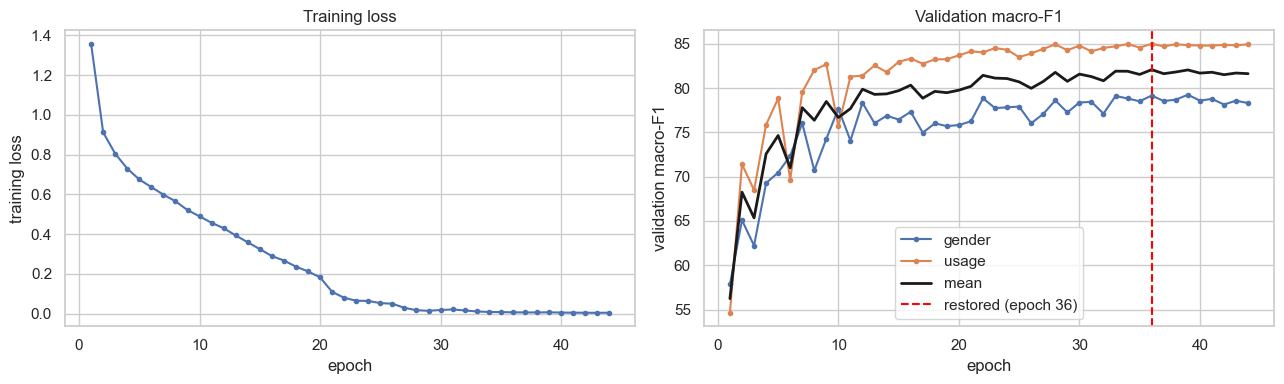

In [11]:
# ============================================
# CELL 11 - Train the model
# ============================================

print("Training the reference configuration: VGG-style blocks, early branching,")
print("ReLU, max pooling, flatten head.\n")

run("base", lambda: EarlyBranchCNN(NUM_CLASSES))

history = HISTORIES["base"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["epoch"], history["train_loss"], marker=".")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss")
axes[1].plot(history["epoch"], history["val_gender_f1"], marker=".", label="gender")
axes[1].plot(history["epoch"], history["val_usage_f1"], marker=".", label="usage")
axes[1].plot(history["epoch"], history["val_mean_f1"], "k-", lw=2, label="mean")
best_epoch = history.loc[history["val_mean_f1"].idxmax(), "epoch"]
axes[1].axvline(best_epoch, ls="--", color="red", label=f"restored (epoch {int(best_epoch)})")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation macro-F1")
axes[1].set_title("Validation macro-F1"); axes[1].legend()
plt.tight_layout(); plt.show()

## Part 5: Class imbalance

`usage` is 77% `Casual`. In a batch of 128 images drawn at random, roughly 99 are Casual and 7
are Formal, so the network sees the majority class an order of magnitude more often.

The first step is to establish the mechanism by which the imbalance harms performance, because
the symptom is easily misdiagnosed. If the network were labelling everything `Casual`, that class
would be substantially over-predicted and its precision would be low. Cell 12 tests this before
any correction is applied.

Three corrections are then evaluated:

1. **Balanced batch sampling**: construct each batch with equal numbers of each class, drawn
   fresh from the full pool. This has the same effect as duplicating minority rows, without
   repeating fixed copies that the network can memorise.
2. **Balanced sampling with mild augmentation**: adding horizontal flips and small
   scale/translation jitter. Rotation is deliberately excluded: the evaluation images are
   upright catalogue photographs, so training on tilted garments would spend capacity on a
   situation that never occurs.
3. **Per-head class weights**: leaving the sampling alone and weighting the loss instead, so that
   an error on a rare class costs proportionally more. Because the weight sits inside each
   attribute's own cross-entropy, gender and usage can be corrected independently, which is
   precisely what a sampler over shared batches cannot do: equalising one attribute's classes in
   a batch fixes the composition of the other's.

All three alter how the network is trained rather than how its outputs are interpreted.

Each correction is judged on two quantities: macro-F1, which is the metric the model is selected
on, and the recall of the weakest `usage` class, which is what the correction is intended to
raise. The two need not move together. Because one network predicts both attributes, the
effect of a usage-balanced sampler on the gender head is measured as well, since a sampler that
equalises one attribute necessarily unbalances the other, and whether that costs anything is a
question for measurement rather than for the argument.

In [12]:
# ============================================
# CELL 12 - Diagnosing the cost of the imbalance
# ============================================

base_val = predict(MODELS["base"], val_loader)

print(classification_report(base_val["usage"]["true"], base_val["usage"]["pred"],
                            target_names=class_names["usage"], zero_division=0, digits=3))

predicted = Counter(base_val["usage"]["pred"])
actual = Counter(base_val["usage"]["true"])
comparison = pd.DataFrame({
    "class": class_names["usage"],
    "actual": [actual[i] for i in range(NUM_CLASSES["usage"])],
    "predicted": [predicted[i] for i in range(NUM_CLASSES["usage"])],
})
comparison["over-predicted by"] = comparison["predicted"] - comparison["actual"]
display(comparison)

recall = [np.mean(base_val["usage"]["pred"][base_val["usage"]["true"] == i] == i)
          for i in range(NUM_CLASSES["usage"])]
weakest = int(np.argmin(recall))
print(f"weakest class: {class_names['usage'][weakest]}, "
      f"recall {recall[weakest] * 100:.1f}%")
print("Indiscriminate prediction of the majority class would show as a large positive")
print("over-prediction count for Casual together with low precision on that class.")
print("The table above determines whether that is the mechanism at work here.")

              precision    recall  f1-score   support

      Casual      0.934     0.957     0.945      4231
      Ethnic      0.920     0.883     0.901       367
      Formal      0.876     0.787     0.829       342
      Sports      0.764     0.689     0.725       560

    accuracy                          0.914      5500
   macro avg      0.874     0.829     0.850      5500
weighted avg      0.912     0.914     0.913      5500



,class,actual,predicted,over-predicted by
0,Casual,4231,4336,105
1,Ethnic,367,352,-15
2,Formal,342,307,-35
3,Sports,560,505,-55


weakest class: Sports, recall 68.9%
Indiscriminate prediction of the majority class would show as a large positive
over-prediction count for Casual together with low precision on that class.
The table above determines whether that is the mechanism at work here.


In [13]:
# ============================================
# CELL 13 - Balanced batch sampling
# ============================================

class BalancedBatchSampler(Sampler):
    """Each batch holds an equal number of every class, sampled with replacement
    from the full pool so minority items are not repeated in fixed combinations."""

    def __init__(self, labels, batch_size=128, batches_per_epoch=None, seed=RANDOM_STATE):
        self.labels = np.asarray(labels)
        self.classes = np.unique(self.labels)
        self.per_class = max(1, batch_size // len(self.classes))
        self.batch_size = self.per_class * len(self.classes)
        self.by_class = {c: np.where(self.labels == c)[0] for c in self.classes}
        self.batches_per_epoch = batches_per_epoch or (len(self.labels) // self.batch_size)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            batch = []
            for cls in self.classes:
                pool = self.by_class[cls]
                batch.extend(self.rng.choice(pool, self.per_class,
                                             replace=len(pool) < self.per_class))
            self.rng.shuffle(batch)
            yield [int(i) for i in batch]


sampler = BalancedBatchSampler(train_df["usage_y"].to_numpy(), CONFIG["batch_size"])
print(f"batch composition: {sampler.per_class} per class x "
      f"{len(sampler.classes)} classes = {sampler.batch_size} images")
print(f"batches per epoch: {len(sampler)}")

natural = train_df["usage_y"].value_counts(normalize=True).sort_index()
print("\nusage share per batch, before and after balancing:")
display(pd.DataFrame({
    "class": class_names["usage"],
    "natural %": (natural.values * 100).round(1),
    "balanced %": [round(100 / len(sampler.classes), 1)] * len(sampler.classes)}))

balanced_loader = make_loader(train_df, batch_sampler=sampler)
run("balanced", lambda: EarlyBranchCNN(NUM_CLASSES), loader_train=balanced_loader)

batch composition: 32 per class x 4 classes = 128 images
batches per epoch: 214

usage share per batch, before and after balancing:


,class,natural %,balanced %
0,Casual,77.1,25.0
1,Ethnic,6.7,25.0
2,Formal,5.9,25.0
3,Sports,10.2,25.0


  [balanced] epoch  1/50 loss 1.2117 val mean macro-F1 50.70  best
  [balanced] epoch  2/50 loss 0.7220 val mean macro-F1 57.95  best
  [balanced] epoch  3/50 loss 0.6130 val mean macro-F1 60.34  best
  [balanced] epoch  4/50 loss 0.5286 val mean macro-F1 65.42  best
  [balanced] epoch  5/50 loss 0.4619 val mean macro-F1 69.22  best
  [balanced] epoch  6/50 loss 0.4019 val mean macro-F1 72.08  best
  [balanced] epoch  7/50 loss 0.3629 val mean macro-F1 72.68  best
  [balanced] epoch  8/50 loss 0.3309 val mean macro-F1 72.78  best
  [balanced] epoch  9/50 loss 0.3043 val mean macro-F1 74.23  best
  [balanced] epoch 10/50 loss 0.2705 val mean macro-F1 75.98  best
  [balanced] epoch 14/50 loss 0.1992 val mean macro-F1 78.40  best
  [balanced] epoch 15/50 loss 0.1860 val mean macro-F1 80.02  best
  [balanced] epoch 20/50 loss 0.1022 val mean macro-F1 79.16
  [balanced] epoch 21/50 loss 0.0855 val mean macro-F1 80.08  best
  [balanced] epoch 22/50 loss 0.0744 val mean macro-F1 80.09  best
 

EarlyBranchCNN(
  (shared): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (branches): Mod

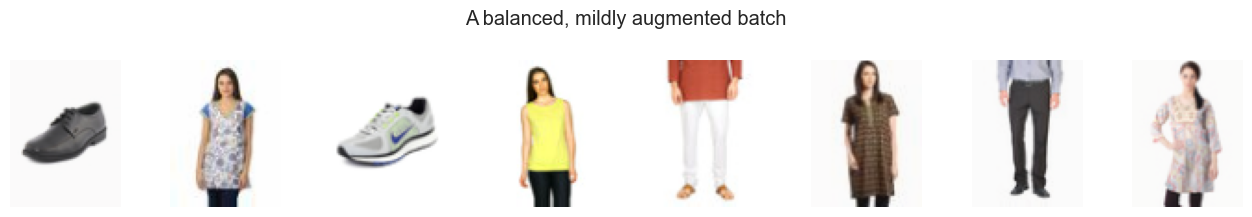

  [balanced_aug] epoch  1/50 loss 1.3089 val mean macro-F1 48.08  best
  [balanced_aug] epoch  2/50 loss 0.9125 val mean macro-F1 57.60  best
  [balanced_aug] epoch  3/50 loss 0.8085 val mean macro-F1 66.08  best
  [balanced_aug] epoch  5/50 loss 0.6978 val mean macro-F1 66.67  best
  [balanced_aug] epoch  6/50 loss 0.6370 val mean macro-F1 66.80  best
  [balanced_aug] epoch  8/50 loss 0.5752 val mean macro-F1 67.94  best
  [balanced_aug] epoch 10/50 loss 0.5295 val mean macro-F1 73.05  best
  [balanced_aug] epoch 14/50 loss 0.4511 val mean macro-F1 73.42  best
  [balanced_aug] epoch 15/50 loss 0.4266 val mean macro-F1 72.72
  [balanced_aug] epoch 19/50 loss 0.3434 val mean macro-F1 74.10  best
  [balanced_aug] epoch 20/50 loss 0.3242 val mean macro-F1 71.47
  [balanced_aug] epoch 21/50 loss 0.3045 val mean macro-F1 74.99  best
  [balanced_aug] epoch 22/50 loss 0.2975 val mean macro-F1 76.88  best
  [balanced_aug] epoch 25/50 loss 0.2757 val mean macro-F1 78.24  best
  [balanced_aug] e

EarlyBranchCNN(
  (shared): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (branches): Mod

In [14]:
# ============================================
# CELL 14 - Balanced sampling with mild augmentation
# ============================================

def gentle_augment(tensor):
    """Horizontal flip, small scale and translation, mild brightness.

    No rotation: the evaluation images are upright, so tilted training examples
    would not resemble anything the model is asked to classify.
    """
    if torch.rand(1).item() < 0.5:
        tensor = torch.flip(tensor, dims=[2])

    scale = 1.0 + (torch.rand(1).item() * 2 - 1) * 0.10
    shift_x = (torch.rand(1).item() * 2 - 1) * 0.05
    shift_y = (torch.rand(1).item() * 2 - 1) * 0.05
    theta = torch.tensor([[1 / scale, 0.0, shift_x],
                          [0.0, 1 / scale, shift_y]], dtype=torch.float32).unsqueeze(0)
    grid = F.affine_grid(theta, (1,) + tuple(tensor.shape), align_corners=False)
    tensor = F.grid_sample(tensor.unsqueeze(0), grid, align_corners=False,
                           padding_mode="border").squeeze(0)

    tensor = tensor * (1.0 + (torch.rand(1).item() * 2 - 1) * 0.10)
    return tensor


augmented_loader = make_loader(
    train_df,
    batch_sampler=BalancedBatchSampler(train_df["usage_y"].to_numpy(),
                                       CONFIG["batch_size"], seed=RANDOM_STATE + 1),
    transform=gentle_augment)

# what the augmentation actually does
sample_images, _, _ = next(iter(augmented_loader))
denorm = (sample_images[:8] * STD_T + MEAN_T).permute(0, 2, 3, 1).numpy()
fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for ax, image in zip(axes, denorm):
    ax.imshow(np.clip(image, 0, 1)); ax.axis("off")
plt.suptitle("A balanced, mildly augmented batch")
plt.tight_layout(); plt.show()

# Augmentation presents a slightly different image each epoch, so this configuration
# converges more slowly than the others. The shared cap in CELL 1 is set wide
# enough for it, and early stopping ends the faster runs sooner.
run("balanced_aug", lambda: EarlyBranchCNN(NUM_CLASSES), loader_train=augmented_loader)

In [15]:
# ============================================
# CELL 15 - Per-head class weights
# ============================================

# A sampler equalises one attribute by changing which images are drawn, which necessarily
# changes the composition of the other - Cell 17 measures by how much. Weighting the loss
# reaches the same end by a different route: every image is still drawn at its natural
# rate, and a mistake on a rare class simply counts for more. Because the weight sits
# inside each head's own cross-entropy, gender and usage are corrected independently,
# which is the one thing a sampler over shared batches cannot do.

def inverse_frequency_weights(labels, n_classes):
    """w = N / (K * count), rescaled so that the mean weight is one.

    The rescaling matters. It leaves the magnitude of the loss, and with it the effective
    step size, comparable with the unweighted runs, so the comparison is about the
    weighting rather than about an accidental change in learning rate.
    """
    counts = np.bincount(labels, minlength=n_classes).astype(np.float64)
    weights = len(labels) / (n_classes * np.maximum(counts, 1))
    return weights / weights.mean()


CLASS_WEIGHTS = {target: inverse_frequency_weights(train_df[target + "_y"].to_numpy(),
                                                   NUM_CLASSES[target])
                 for target in CONFIG["targets"]}

display(pd.concat([
    pd.DataFrame({"attribute": target,
                  "class": class_names[target],
                  "train share %": (np.bincount(train_df[target + "_y"].to_numpy(),
                                                minlength=NUM_CLASSES[target])
                                    / len(train_df) * 100).round(2),
                  "loss weight": CLASS_WEIGHTS[target].round(2)})
    for target in CONFIG["targets"]], ignore_index=True))

run("class_weighted", lambda: EarlyBranchCNN(NUM_CLASSES),
    config={"class_weights": {t: CLASS_WEIGHTS[t].tolist() for t in CONFIG["targets"]}})


# The three classes these corrections are aimed at. They are weak for different reasons:
# Girls is simply rare, Sports is confusable with Casual because a sports t-shirt is a
# t-shirt, and Unisex is genuinely ambiguous - a watch or a bag that both ranges sell.
# Weighting the loss raises recall on a rare class almost by construction, since errors
# there now cost more, so the question is whether it does so without spending accuracy
# elsewhere. The next cell answers that; this table shows where the effect is aimed.
APPROACHES = [("no correction", "base"),
              ("balanced sampling", "balanced"),
              ("balanced + augmentation", "balanced_aug"),
              ("per-head class weights", "class_weighted")]
VAL_PREDICTIONS = {tag: predict(MODELS[tag], val_loader) for _, tag in APPROACHES}

WEAK_CLASSES = [("usage", "Sports"), ("gender", "Unisex"), ("gender", "Girls")]


def class_recall(predictions, target, name):
    index = class_names[target].index(name)
    actual = predictions[target]["true"] == index
    return float((predictions[target]["pred"][actual] == index).mean() * 100)


weak = pd.DataFrame([
    {"attribute": target, "class": name,
     **{tag: round(class_recall(VAL_PREDICTIONS[tag], target, name), 1)
        for _, tag in APPROACHES}}
    for target, name in WEAK_CLASSES])
display(weak)
print("Recall on the three weakest classes, validation split, one seed each.")
weak.to_csv(ARTIFACT_DIR / "weak_class_recall.csv", index=False)


,attribute,class,train share %,loss weight
0,gender,Boys,2.07,1.79
1,gender,Girls,1.57,2.36
2,gender,Men,54.38,0.07
3,gender,Unisex,5.46,0.68
4,gender,Women,36.53,0.10
5,usage,Casual,77.11,0.12
6,usage,Ethnic,6.74,1.39
7,usage,Formal,5.93,1.58
8,usage,Sports,10.22,0.91


  [class_weighted] epoch  1/50 loss 2.0808 val mean macro-F1 54.49  best
  [class_weighted] epoch  2/50 loss 1.5242 val mean macro-F1 56.64  best
  [class_weighted] epoch  3/50 loss 1.3297 val mean macro-F1 62.01  best
  [class_weighted] epoch  5/50 loss 1.1365 val mean macro-F1 65.23  best
  [class_weighted] epoch  6/50 loss 1.0726 val mean macro-F1 69.11  best
  [class_weighted] epoch  7/50 loss 0.9966 val mean macro-F1 73.58  best
  [class_weighted] epoch 10/50 loss 0.8033 val mean macro-F1 69.50
  [class_weighted] epoch 12/50 loss 0.6158 val mean macro-F1 74.71  best
  [class_weighted] epoch 13/50 loss 0.5471 val mean macro-F1 74.83  best
  [class_weighted] epoch 14/50 loss 0.5146 val mean macro-F1 75.08  best
  [class_weighted] epoch 15/50 loss 0.4746 val mean macro-F1 74.38
  [class_weighted] epoch 16/50 loss 0.4430 val mean macro-F1 75.42  best
  [class_weighted] epoch 17/50 loss 0.4278 val mean macro-F1 75.96  best
  [class_weighted] epoch 18/50 loss 0.4084 val mean macro-F1 77

,attribute,class,base,balanced,balanced_aug,class_weighted
0,usage,Sports,68.9,71.6,82.5,73.0
1,gender,Unisex,60.5,50.7,53.4,72.1
2,gender,Girls,69.1,70.9,61.8,71.8


Recall on the three weakest classes, validation split, one seed each.


,approach,mean macro-F1,usage macro-F1,gender macro-F1,weakest usage recall,change vs none
0,no correction,82.09,85.01,79.16,68.93,0.00
1,balanced sampling,80.97,84.67,77.26,71.61,-1.12
2,balanced + augmentation,80.82,83.65,77.98,82.50,-1.27
3,per-head class weights,81.88,84.37,79.39,73.04,-0.21


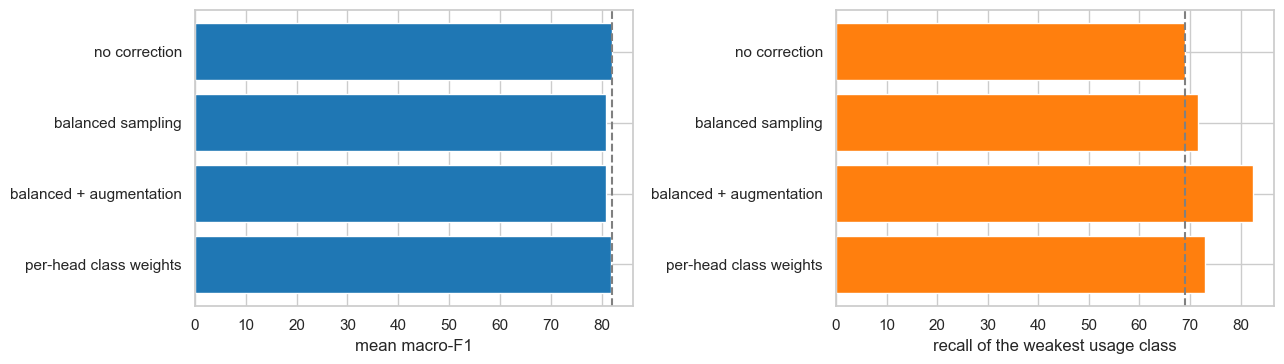

In [16]:
# ============================================
# CELL 16 - Comparison of the three corrections
# ============================================

def weakest_recall(predictions, target="usage"):
    return min(np.mean(predictions[target]["pred"][predictions[target]["true"] == i] == i)
               for i in range(NUM_CLASSES[target])) * 100


rows = [{"approach": label,
         "mean macro-F1": RESULTS[tag]["mean_macro_f1"],
         "usage macro-F1": RESULTS[tag]["usage"]["macro_f1"],
         "gender macro-F1": RESULTS[tag]["gender"]["macro_f1"],
         "weakest usage recall": weakest_recall(VAL_PREDICTIONS[tag])}
        for label, tag in APPROACHES]

imbalance = pd.DataFrame(rows).round(2)
imbalance["change vs none"] = (imbalance["mean macro-F1"]
                               - imbalance["mean macro-F1"].iloc[0]).round(2)
display(imbalance)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].barh(imbalance["approach"], imbalance["mean macro-F1"], color="tab:blue")
axes[0].axvline(imbalance["mean macro-F1"].iloc[0], ls="--", color="grey")
axes[0].set_xlabel("mean macro-F1"); axes[0].invert_yaxis()
axes[1].barh(imbalance["approach"], imbalance["weakest usage recall"], color="tab:orange")
axes[1].axvline(imbalance["weakest usage recall"].iloc[0], ls="--", color="grey")
axes[1].set_xlabel("recall of the weakest usage class"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

imbalance.to_csv(ARTIFACT_DIR / "imbalance_comparison.csv", index=False)

,approach,gender macro-F1,usage macro-F1,gender change,usage change
0,no correction,79.16,85.01,0.00,0.00
1,balanced sampling,77.26,84.67,-1.90,-0.34
2,balanced + augmentation,77.98,83.65,-1.18,-1.36
3,per-head class weights,79.39,84.37,0.23,-0.64


Gender composition of each usage class in the training split (%):


gender_label,Boys,Girls,Men,Unisex,Women
usage_label,,,,,
Casual,2.6,2.0,53.2,6.1,36.1
Ethnic,0.4,0.3,3.9,0.0,95.5
Formal,0.0,0.0,94.9,0.1,5.0
Sports,0.5,0.0,73.1,7.5,18.9


,natural %,balanced batches %,ratio
gender_label,,,
Boys,2.1,0.9,0.43
Girls,1.6,0.6,0.37
Men,54.4,56.3,1.03
Unisex,5.5,3.4,0.62
Women,36.5,38.9,1.07


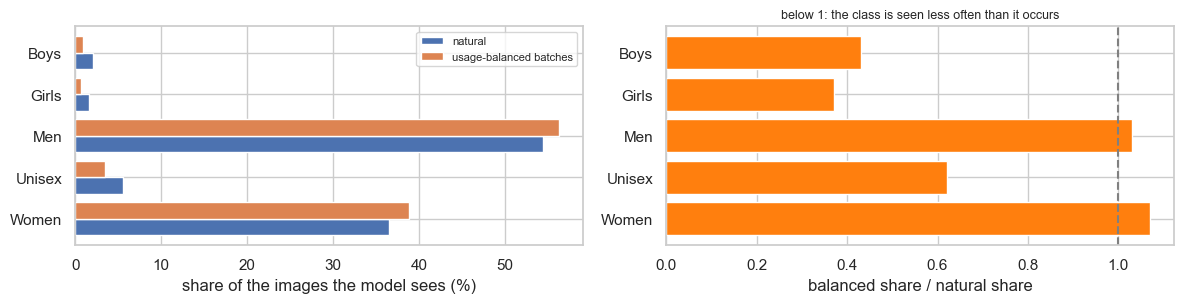

Balanced sampling changed usage macro-F1 by -0.34 and gender macro-F1 by -1.90.

The minority usage classes are dominated by the majority genders (Ethnic is 95% Women, Formal is 95% Men),
so drawing them equally makes the rare gender classes rarer still: Girls falls from 1.6%
to 0.6% of the images the model sees, a factor of 0.37.
Gender macro-F1 weights all five classes equally, and that is where the cost appears:
gender macro-F1 moved -1.90.

Every configuration here is a single run. Part 6 states the margin below which
a difference between two of them is not evidence.


In [17]:
# ============================================
# CELL 17 - The effect of the sampler on the other attribute
# ============================================

# The sampler equalises the four usage classes. Gender and usage are not
# independent, so changing one distribution changes the other. This cell measures
# what the gender head is trained on once the sampler is in place.

attribute_cost = pd.DataFrame([
    {"approach": label,
     "gender macro-F1": round(RESULTS[tag]["gender"]["macro_f1"], 2),
     "usage macro-F1": round(RESULTS[tag]["usage"]["macro_f1"], 2)}
    for label, tag in APPROACHES])
for column in ["gender macro-F1", "usage macro-F1"]:
    attribute_cost[column.replace("macro-F1", "change")] = (
        attribute_cost[column] - attribute_cost[column].iloc[0]).round(2)
display(attribute_cost)

# The composition of each usage class is what the sampler re-weights.
mix = pd.crosstab(train_df["usage_label"], train_df["gender_label"],
                  normalize="index") * 100
print("Gender composition of each usage class in the training split (%):")
display(mix.round(1))

# With equal numbers of every usage class in each batch, the gender distribution
# the model sees becomes the unweighted mean of the rows above, not the true one.
natural = train_df["gender_label"].value_counts(normalize=True).sort_index() * 100
exposure = pd.DataFrame({"natural %": natural.round(1),
                         "balanced batches %": mix.mean(axis=0).round(1)})
exposure["ratio"] = (exposure["balanced batches %"] / exposure["natural %"]).round(2)
display(exposure)

offset = np.arange(len(exposure))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].barh(offset + 0.2, exposure["natural %"], height=0.4, label="natural")
axes[0].barh(offset - 0.2, exposure["balanced batches %"], height=0.4,
             label="usage-balanced batches")
axes[0].set_xlabel("share of the images the model sees (%)")
axes[0].legend(fontsize=8)

axes[1].barh(offset, exposure["ratio"], color="tab:orange")
axes[1].axvline(1.0, ls="--", color="grey")
axes[1].set_xlabel("balanced share / natural share")
axes[1].set_title("below 1: the class is seen less often than it occurs", fontsize=9)

for ax in axes:
    ax.set_yticks(offset); ax.set_yticklabels(exposure.index); ax.invert_yaxis()
plt.tight_layout(); plt.show()

dominant = mix.idxmax(axis=1)
skewed = ", ".join(f"{usage} is {mix.loc[usage, dominant[usage]]:.0f}% {dominant[usage]}"
                   for usage in mix.index if mix.loc[usage, dominant[usage]] > 80)
starved = exposure["ratio"].idxmin()

print(f"Balanced sampling changed usage macro-F1 by "
      f"{attribute_cost.loc[1, 'usage change']:+.2f} and gender macro-F1 by "
      f"{attribute_cost.loc[1, 'gender change']:+.2f}.")
print(f"\nThe minority usage classes are dominated by the majority genders ({skewed}),")
print(f"so drawing them equally makes the rare gender classes rarer still: {starved} falls "
      f"from {exposure.loc[starved, 'natural %']:.1f}%")
print(f"to {exposure.loc[starved, 'balanced batches %']:.1f}% of the images the model sees, "
      f"a factor of {exposure.loc[starved, 'ratio']:.2f}.")
# The exposure table above establishes a mechanism by which the sampler *could* cost
# gender accuracy. Whether it did is a separate question, settled by measurement rather
# than by the mechanism, and the answer is not fixed in advance.
gender_change = attribute_cost.loc[1, "gender change"]
if gender_change < 0:
    print("Gender macro-F1 weights all five classes equally, and that is where the cost "
          f"appears:\ngender macro-F1 moved {gender_change:+.2f}.")
else:
    print("Gender macro-F1 weights all five classes equally, so a thinner exposure to the "
          "rare\ngenders is where a cost would show. On this run it did not show: gender "
          f"macro-F1 moved\n{gender_change:+.2f}. The distortion in the batches is real and "
          "measured above; the loss it\npredicts is not present in the result.")
print("\nEvery configuration here is a single run. Part 6 states the margin below which\n"
      "a difference between two of them is not evidence.")

exposure.to_csv(ARTIFACT_DIR / "sampler_gender_exposure.csv")


## Part 6: Model selection and test results

Selection is performed on the validation partition alone. The test partition is held out until
the model is fixed, and is evaluated exactly once.

Two quantities bound how precisely two configurations can be compared. The first is the sampling
error of the validation set, which reflects its finite size. The second is the variation between
independent training runs of the same configuration, which arises from the random initialisation,
the ordering of batches, and non-deterministic GPU kernels. A difference smaller than either
quantity is not evidence of a difference in the configurations.

Every criterion in the selection rule is judged against that same threshold, including the
tie-break: a difference too small to separate two configurations on the primary metric cannot
decide between them on a secondary one either. Where nothing separates the candidates, the
configuration requiring the least machinery is retained.

### Run-to-run variability

A configuration's score moves between runs of identical code: the weights are initialised
randomly, the batch ordering differs, and several GPU kernels are non-deterministic. One run
therefore cannot establish on its own that one configuration is better than another.

Each configuration here is therefore trained three times, under three seeds and a common epoch
cap, and the training variance is measured from those repeats rather than assumed: the threshold
takes the largest standard deviation any configuration shows across its seeds, which is the
conservative choice because it widens the threshold. An earlier version of this notebook trained
each configuration once and carried the figure over from a previous experiment, which left a prior
deciding a ranking; the code keeps that fallback for the single-seed case and labels it as carried
over whenever it is used, but here the number is measured. Dropping the term altogether would
leave the sampling error alone to decide the ranking, which is precisely the error this section
exists to prevent.

The larger of the two uncertainties, sampling error and training variance, is the threshold
below which two configurations are treated as indistinguishable.


In [18]:
# ============================================
# CELL 18 - Collecting the trained configurations
# ============================================

# Three seeds per configuration. A run at 60x80 costs roughly a quarter of what it cost
# at 120x160, and repeats are exactly what the earlier comparison lacked: with one run each
# the training variance had to be carried over from an older experiment, so a prior decided
# the ranking. Twelve runs replace it with a spread measured on this data, this architecture
# and this resolution. The first seed of each configuration is the one Parts 4 and 5 already
# used, so those four models are collected here rather than retrained.
SEEDS = [RANDOM_STATE, 7, 13]
CONFIGURATIONS = [tag for _, tag in APPROACHES]


def config_for(name):
    """Configuration overrides a run needs; None means the defaults from CELL 1."""
    if name == "class_weighted":
        return {"class_weights": {t: CLASS_WEIGHTS[t].tolist() for t in CONFIG["targets"]}}
    return None


def build_base():
    return EarlyBranchCNN(NUM_CLASSES)


def loader_for(name, seed):
    """The training loader a configuration needs; None means the default loader."""
    if name == "balanced":
        return make_loader(train_df, batch_sampler=BalancedBatchSampler(
            train_df["usage_y"].to_numpy(), CONFIG["batch_size"], seed=seed))
    if name == "balanced_aug":
        return make_loader(train_df, batch_sampler=BalancedBatchSampler(
            train_df["usage_y"].to_numpy(), CONFIG["batch_size"], seed=seed + 1),
            transform=gentle_augment)
    return None


repeat_rows, seed_models = [], {}

for name in CONFIGURATIONS:
    for seed in SEEDS:
        tag = f"{name}-s{seed}"
        if seed == SEEDS[0] and name in RESULTS:       # already trained in Part 5
            summary, model, history = RESULTS[name], MODELS[name], HISTORIES[name]
        else:
            set_seed(seed)
            model, history = train_model(build_base(), tag, config=config_for(name),
                                         loader_train=loader_for(name, seed), verbose=False)
            summary = summarise(predict(model, val_loader))
        seed_models[(name, seed)] = model
        repeat_rows.append({
            "configuration": name, "seed": seed,
            "mean macro-F1": round(summary["mean_macro_f1"], 2),
            "usage macro-F1": round(summary["usage"]["macro_f1"], 2),
            "gender macro-F1": round(summary["gender"]["macro_f1"], 2),
            "exact match": round(summary["exact_match"], 2),
            # Recorded so that a run truncated by the epoch cap can be identified rather
            # than assumed: a configuration whose best epoch is the last one it was allowed
            # was still improving, and its score is a floor.
            "best epoch": int(history.loc[history["val_mean_f1"].idxmax(), "epoch"]),
            "epochs run": int(history["epoch"].max())})
        print(f"  {name:9s} seed {seed:>4} -> mean {repeat_rows[-1]['mean macro-F1']:6.2f} | "
              f"usage {repeat_rows[-1]['usage macro-F1']:6.2f} | "
              f"gender {repeat_rows[-1]['gender macro-F1']:6.2f}")

repeats = pd.DataFrame(repeat_rows)
display(repeats)


  base      seed   42 -> mean  82.09 | usage  85.01 | gender  79.16
  base      seed    7 -> mean  81.44 | usage  84.25 | gender  78.64
  base      seed   13 -> mean  81.52 | usage  84.54 | gender  78.49
  balanced  seed   42 -> mean  80.97 | usage  84.67 | gender  77.26
  balanced  seed    7 -> mean  81.54 | usage  84.18 | gender  78.89
  balanced  seed   13 -> mean  81.30 | usage  84.77 | gender  77.84
  balanced_aug seed   42 -> mean  80.82 | usage  83.65 | gender  77.98
  balanced_aug seed    7 -> mean  80.10 | usage  84.58 | gender  75.63
  balanced_aug seed   13 -> mean  79.97 | usage  83.70 | gender  76.23
  class_weighted seed   42 -> mean  81.88 | usage  84.37 | gender  79.39
  class_weighted seed    7 -> mean  81.40 | usage  84.09 | gender  78.71
  class_weighted seed   13 -> mean  80.99 | usage  84.51 | gender  77.47


,configuration,seed,mean macro-F1,usage macro-F1,gender macro-F1,exact match,best epoch,epochs run
0,base,42,82.09,85.01,79.16,83.04,36,44
1,base,7,81.44,84.25,78.64,81.25,13,21
2,base,13,81.52,84.54,78.49,82.56,33,41
3,balanced,42,80.97,84.67,77.26,82.02,29,37
4,balanced,7,81.54,84.18,78.89,82.45,42,50
5,balanced,13,81.30,84.77,77.84,81.64,27,35
6,balanced_aug,42,80.82,83.65,77.98,80.25,45,50
7,balanced_aug,7,80.10,84.58,75.63,80.27,41,49
8,balanced_aug,13,79.97,83.70,76.23,80.35,48,50
9,class_weighted,42,81.88,84.37,79.39,80.85,33,41


,runs,mean,sd,usage_mean,usage_sd,exact_mean
configuration,,,,,,
balanced,3,81.27,0.29,84.54,0.32,82.04
balanced_aug,3,80.30,0.46,83.98,0.52,80.29
base,3,81.68,0.35,84.60,0.38,82.28
class_weighted,3,81.42,0.45,84.32,0.21,81.05


4 of 12 runs reached the 50-epoch cap while still improving, and their scores are floors:
  balanced_aug    seed  42  best epoch 45 of 50
  balanced_aug    seed  13  best epoch 48 of 50
  class_weighted  seed   7  best epoch 47 of 50
  class_weighted  seed  13  best epoch 49 of 50
Every run converged for: ['base', 'balanced'].
Where a truncated configuration ranks below one that converged, the margin between
them is an upper bound rather than a measurement.

sampling error of the validation set    : +-0.67
training variance (measured across seeds): +-0.46
threshold for a meaningful difference   : +-0.67



,mean macro-F1,vs leader,usage macro-F1,usage vs leader,within threshold
configuration,,,,,
base,81.68,0.00,84.60,0.00,True
class_weighted,81.42,-0.26,84.32,-0.28,True
balanced,81.27,-0.41,84.54,-0.06,True
balanced_aug,80.30,-1.38,83.98,-0.62,False


leading configuration: base

  class_weighted indistinguishable from the leader on the mean (-0.26);
                 usage macro-F1 -0.28 against the leader
  balanced       indistinguishable from the leader on the mean (-0.41);
                 usage macro-F1 -0.06 against the leader
  balanced_aug   below the leader by more than the threshold (-1.38);
                 usage macro-F1 -0.62 against the leader

Within the threshold of the leader: ['base', 'class_weighted', 'balanced'].
Selection in the next cell ranks on this table and breaks remaining ties on
usage macro-F1, the attribute the corrections in Part 5 were intended to improve.


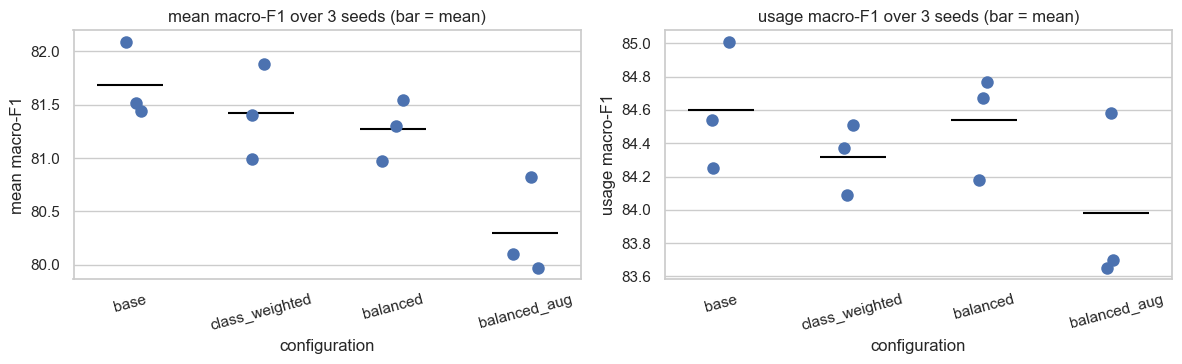

In [29]:
# ============================================
# CELL 19 - Decomposing the uncertainty
# ============================================

stats = repeats.groupby("configuration").agg(
    runs=("mean macro-F1", "size"),
    mean=("mean macro-F1", "mean"), sd=("mean macro-F1", "std"),
    usage_mean=("usage macro-F1", "mean"), usage_sd=("usage macro-F1", "std"),
    exact_mean=("exact match", "mean")).round(2)
display(stats)

# The epoch cap is a source of bias rather than variance, and it belongs here because a run
# that exhausted its budget was compared at a disadvantage. Early stopping fires once a run
# has gone `early_stopping_patience` epochs without improving; a run that reached the cap
# with a shorter stale streak than that was still improving when it was cut off, and its
# score is a floor rather than a peak. Testing the best epoch against the cap on its own is
# not enough - a run whose best epoch was 45 of 50 never got the chance to stop.
budget = repeats.assign(
    stale=repeats["epochs run"] - repeats["best epoch"],
    truncated=((repeats["epochs run"] >= CONFIG["max_epochs"])
               & ((repeats["epochs run"] - repeats["best epoch"])
                  < CONFIG["early_stopping_patience"])))
if budget["truncated"].any():
    cut = budget[budget["truncated"]]
    print(f"{len(cut)} of {len(budget)} runs reached the {CONFIG['max_epochs']}-epoch cap while "
          f"still improving, and their scores are floors:")
    for _, row in cut.iterrows():
        print(f"  {row['configuration']:15s} seed {row['seed']:>3}  best epoch "
              f"{row['best epoch']:>2} of {row['epochs run']}")
    converged = [name for name in CONFIGURATIONS
                 if name not in set(cut["configuration"])]
    print(f"Every run converged for: {converged}.")
    print("Where a truncated configuration ranks below one that converged, the margin between\n"
          "them is an upper bound rather than a measurement.\n")
else:
    print(f"Every run stopped on patience rather than on the {CONFIG['max_epochs']}-epoch cap, "
          f"so the budget truncates nothing.\n")

# Sampling error of a proportion estimated on the validation set: the uncertainty
# attributable to its finite size alone.
NOISE_FLOOR = 100 * np.sqrt(0.5 * 0.5 / len(val_df))

# Training variance, measured here as the largest standard deviation any configuration
# shows across its seeds. Taking the largest rather than pooling is the conservative
# reading: it widens the threshold, which makes a difference harder to claim.
#
# PRIOR_SEED_SD below is only a fallback for the single-seed case, where there is nothing
# to take a standard deviation over. It is the figure an earlier three-seed repeat of this
# notebook produced, and wherever it is used instead of a measurement it is printed as
# carried over. Without it, `max()` would silently discard the NaN and leave the sampling
# error alone deciding the ranking - the exact failure this section exists to prevent.
PRIOR_SEED_SD = 1.17
measured = repeats.groupby("configuration")["mean macro-F1"].std().max()
if np.isfinite(measured):
    spread, SPREAD_SOURCE = float(measured), "measured across seeds"
else:
    spread, SPREAD_SOURCE = PRIOR_SEED_SD, "carried over, not measured on this run"
EFFECTIVE_NOISE = max(NOISE_FLOOR, spread)

print(f"sampling error of the validation set    : +-{NOISE_FLOOR:.2f}")
print(f"training variance ({SPREAD_SOURCE}): +-{spread:.2f}")
print(f"threshold for a meaningful difference   : +-{EFFECTIVE_NOISE:.2f}\n")

leader = stats["mean"].idxmax()
gaps = pd.DataFrame({
    "mean macro-F1": stats["mean"],
    "vs leader": (stats["mean"] - stats.loc[leader, "mean"]).round(2),
    "usage macro-F1": stats["usage_mean"],
    "usage vs leader": (stats["usage_mean"] - stats.loc[leader, "usage_mean"]).round(2),
}).sort_values("mean macro-F1", ascending=False)
gaps["within threshold"] = (stats.loc[leader, "mean"] - gaps["mean macro-F1"]) < EFFECTIVE_NOISE
display(gaps)

print(f"leading configuration: {leader}\n")
for name in gaps.index:
    if name == leader:
        continue
    difference, usage_difference = gaps.loc[name, ["vs leader", "usage vs leader"]]
    if abs(difference) < EFFECTIVE_NOISE:
        verdict = "indistinguishable from the leader on the mean"
    else:
        verdict = "below the leader by more than the threshold"
    print(f"  {name:14s} {verdict} ({difference:+.2f});")
    print(f"  {'':14s} usage macro-F1 {usage_difference:+.2f} against the leader")

tied = list(gaps.index[gaps["within threshold"]])
print(f"\nWithin the threshold of the leader: {tied}.")
print("Selection in the next cell ranks on this table and breaks remaining ties on")
print("usage macro-F1, the attribute the corrections in Part 5 were intended to improve.")

# The order is stated explicitly so that each mean bar lands on its own column:
# seaborn orders categories by first appearance, which is not the order of `stats`.
ORDER = list(gaps.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, column, key in [(axes[0], "mean macro-F1", "mean"),
                        (axes[1], "usage macro-F1", "usage_mean")]:
    sns.stripplot(data=repeats, x="configuration", y=column, ax=ax, size=9, order=ORDER)
    for position, name in enumerate(ORDER):
        ax.hlines(stats.loc[name, key], position - 0.25, position + 0.25, color="black")
    ax.set_title(f"{column} over {len(SEEDS)} seed"
                 f"{'s' if len(SEEDS) > 1 else ''} (bar = mean)")
    ax.tick_params(axis="x", labelrotation=15)
plt.tight_layout(); plt.show()

repeats.to_csv(ARTIFACT_DIR / "seed_repeats.csv", index=False)


In [37]:
# ============================================
# CELL 20 - Selection
# ============================================

# Selection rule, fixed before the scores are examined and applied in order:
#   1. rank on mean macro-F1;
#   2. treat every configuration within EFFECTIVE_NOISE of the leader as tied;
#   3. among tied configurations, prefer the one with the higher usage macro-F1,
#      since usage is the attribute the corrections in Part 5 were intended to
#      improve, but only where that advantage itself exceeds EFFECTIVE_NOISE;
#   4. otherwise prefer the simpler pipeline, and then the smaller model.
# Every configuration is trained under the same epoch cap and the same seeds, so the
# ranking compares like with like and each score below is a mean over repeats rather than
# a single run.
#
# Step 3 originally carried no threshold of its own. Applied that way it selected a
# configuration whose usage advantage was smaller than EFFECTIVE_NOISE, which is a
# margin this notebook treats as indistinguishable everywhere else. A criterion
# cannot decide on a difference it has already classified as noise, so the same
# threshold now governs both steps, and step 4 falls through to the configuration
# that requires the least machinery: the standard loader ahead of a custom sampler,
# and a custom sampler ahead of one combined with augmentation.

print(f"validation set: {len(val_df):,} images")
print(f"sampling error       +-{NOISE_FLOOR:.2f}   "
      f"training variance +-{spread:.2f}   "
      f"threshold +-{EFFECTIVE_NOISE:.2f}\n")

averaged = repeats.groupby("configuration")[["mean macro-F1", "usage macro-F1",
                                             "exact match"]].mean()


def score(tag, column, fallback):
    """Seed-averaged score where repeats exist, otherwise the single run."""
    if tag in averaged.index:
        return round(float(averaged.loc[tag, column]), 2)
    return round(fallback, 2)


candidates = CONFIGURATIONS
selection = pd.DataFrame([
    {"model": tag,
     "runs": int((repeats["configuration"] == tag).sum()) or 1,
     "mean macro-F1": score(tag, "mean macro-F1", RESULTS[tag]["mean_macro_f1"]),
     "usage macro-F1": score(tag, "usage macro-F1", RESULTS[tag]["usage"]["macro_f1"]),
     "exact match": score(tag, "exact match", RESULTS[tag]["exact_match"]),
     "parameters": count_parameters(MODELS[tag])}
    for tag in candidates]).sort_values("mean macro-F1", ascending=False)
display(selection)

# Steps 1 and 2.
leader = selection.iloc[0]["model"]
best_score = selection.iloc[0]["mean macro-F1"]
tied = selection[selection["mean macro-F1"] >= best_score - EFFECTIVE_NOISE]

# Step 3, applied only where the tie-break margin clears the same threshold.
leader_usage = float(selection.loc[selection["model"] == leader,
                                   "usage macro-F1"].iloc[0])
decisive = tied[tied["usage macro-F1"] - leader_usage > EFFECTIVE_NOISE]

# Step 4: least machinery first, then fewest parameters.
# Least machinery first: an unweighted loss, then a weight vector handed to that loss,
# then a custom sampler over batches, then a sampler combined with augmentation.
COMPLEXITY = {"base": 0, "class_weighted": 1, "balanced": 2, "balanced_aug": 3}

if len(decisive):
    FINAL_NAME = decisive.sort_values("usage macro-F1",
                                      ascending=False).iloc[0]["model"]
    SELECTION_REASON = "usage macro-F1 is ahead by more than the threshold"
else:
    FINAL_NAME = (tied.assign(complexity=tied["model"].map(COMPLEXITY))
                  .sort_values(["complexity", "parameters"]).iloc[0]["model"])
    SELECTION_REASON = ("no criterion separates the tied configurations by more "
                        "than the threshold,\nso the simplest pipeline is retained")

# Among the seeds trained for the selected configuration, retain the strongest.
seed_scores = repeats[repeats["configuration"] == FINAL_NAME]
if len(seed_scores):
    BEST_SEED = int(seed_scores.sort_values("mean macro-F1",
                                            ascending=False).iloc[0]["seed"])
    FINAL_MODEL = seed_models[(FINAL_NAME, BEST_SEED)]
else:
    BEST_SEED = RANDOM_STATE
    FINAL_MODEL = MODELS[FINAL_NAME]

print(f"within +-{EFFECTIVE_NOISE:.2f} of the leader: {list(tied['model'])}")
if len(tied) > 1:
    print(SELECTION_REASON)
else:
    print("no tie: the leading configuration is ahead by more than the threshold")

print(f"\nselected: {FINAL_NAME}, seed {BEST_SEED}, "
      f"{count_parameters(FINAL_MODEL):,} parameters")

# Which configuration survives this rule is not fixed in advance. If the uncorrected
# pipeline is retained, the corrections stay in the notebook because the diagnosis and
# the negative result are themselves the finding. If a correction is retained instead,
# the qualifier that matters is the budget: both sampler configurations reach their best
# epoch close to the cap while the uncorrected run converges and stops early, so the
# truncation works against the winner rather than for it.
if FINAL_NAME == "base":
    print("\nNo imbalance correction is retained by the rule; see Cell 16 for the "
          "trade-off each produced.")
else:
    print(f"\n{FINAL_NAME} is retained over the uncorrected pipeline; Cell 16 gives the "
          "trade-off it\nproduced. It reached its best epoch near the cap, so its score "
          "is a floor rather than\na peak, and the margin over the uncorrected run is "
          f"{best_score - float(selection.loc[selection['model'] == 'base', 'mean macro-F1'].iloc[0]):.2f} "
          f"against a threshold of {EFFECTIVE_NOISE:.2f}.")

# ------------------------------------------------------- the deployed configuration ----
# The ranking above is one question - which configuration is strongest overall - and the
# deployed model is another. They can differ: an application that tells a user what occasion
# an item suits is judged partly on the sportswear it misses, and `Sports` is the weakest
# class in the notebook. `balanced_aug` raises its recall from 68.9% to 82.5% on validation,
# which no other configuration comes close to, so it was deployed in place of the retained
# configuration and evaluated.
#
# It was then reverted, and the reasoning is kept here rather than deleted.
#
# The recall was real - 64.8% to 83.4% on the test partition - but it was not created, only
# moved. Sports precision fell from 77.7% to 63.3% in the same step, so Sports F1 went from
# 70.7 to 72.0: a gain inside the threshold, bought by making a third of everything the model
# now calls Sports wrong. A sweep of the decision threshold on the retained model traces the
# same curve, which is what a trade along a fixed boundary looks like rather than a better
# boundary.
#
# The cost fell somewhere the change was never aimed at. The sampler equalises `usage`, but
# the two attributes share a trunk, so the gender head's training distribution moves with it -
# the exposure table in Cell 17 puts Girls at 0.37x and Boys at 0.43x their natural rate.
# Gender macro-F1 fell 2.69 and exact match 2.70, against 1.3 gained on Sports F1. Cell 17
# predicts that mechanism from the training data alone; this is it arriving.
#
# So the rule's own answer is restored. Where a correction has to be paid for in an attribute
# it was not meant to touch, the aggregate metric the rule ranks on is measuring something
# real, and overriding it needs a better reason than the class it was aimed at.
#
# Setting DEPLOY_NAME to a configuration name below deploys it in place of the retained one
# and prints the cost. It is left equal to the rule's answer.
RULE_NAME = FINAL_NAME
DEPLOY_NAME = RULE_NAME
DEPLOY_REASON = "the configuration the selection rule retained"

if DEPLOY_NAME != RULE_NAME:
    scores = selection.set_index("model")["mean macro-F1"]
    cost = scores[RULE_NAME] - scores[DEPLOY_NAME]
    FINAL_NAME = DEPLOY_NAME
    seed_scores = repeats[repeats["configuration"] == FINAL_NAME]
    BEST_SEED = int(seed_scores.sort_values("mean macro-F1", ascending=False).iloc[0]["seed"])
    FINAL_MODEL = seed_models[(FINAL_NAME, BEST_SEED)]
    SELECTION_REASON = f"deployment override: {DEPLOY_REASON}"
    print(f"\nthe rule retains  : {RULE_NAME}")
    print(f"deployed instead  : {FINAL_NAME}, seed {BEST_SEED}, on {DEPLOY_REASON}")
    print(f"cost of the choice: {cost:.2f} mean macro-F1, against a threshold of "
          f"{EFFECTIVE_NOISE:.2f}")
else:
    print(f"\ndeployed: {FINAL_NAME}, seed {BEST_SEED} - the configuration the rule retained.")
    print("A deployment override was evaluated (balanced_aug, for Sports recall) and reverted;\n"
          "the comment above this cell records what it measured and why it was withdrawn.")

# One consequence has to be recorded rather than absorbed. Withdrawing that override meant
# reading the test partition to judge a deployment decision, so this task has now consulted
# it twice: once for the retained configuration and once for the override. The evidence that
# reverses the decision is present in validation on its own - `balanced_aug` costs 1.18 gender
# macro-F1 there at the shared seed, and the rule had already excluded it - so the conclusion
# does not depend on the second look. It is noted because a held-out partition that has been
# consulted twice is no longer held out to the same degree, and a reader is entitled to know.


validation set: 5,500 images
sampling error       +-0.67   training variance +-0.46   threshold +-0.67



,model,runs,mean macro-F1,usage macro-F1,exact match,parameters
0,base,3,81.68,84.60,82.28,4249577
3,class_weighted,3,81.42,84.32,81.05,4249577
1,balanced,3,81.27,84.54,82.04,4249577
2,balanced_aug,3,80.30,83.98,80.29,4249577


within +-0.67 of the leader: ['base', 'class_weighted', 'balanced']
no criterion separates the tied configurations by more than the threshold,
so the simplest pipeline is retained

selected: base, seed 42, 4,249,577 parameters

No imbalance correction is retained by the rule; see Cell 16 for the trade-off each produced.

deployed: base, seed 42 - the configuration the rule retained.
A deployment override was evaluated (balanced_aug, for Sports recall) and reverted;
the comment above this cell records what it measured and why it was withdrawn.


,target,accuracy,macro-F1,balanced accuracy,majority baseline,gain
0,gender,90.33,76.37,75.88,54.20,36.13
1,usage,90.24,82.66,81.93,77.11,13.13


exact match (both attributes correct): 81.59%

GENDER
              precision    recall  f1-score   support

        Boys      0.758     0.765     0.761        98
       Girls      0.622     0.592     0.607       103
         Men      0.922     0.949     0.936      2965
      Unisex      0.611     0.588     0.599       262
       Women      0.932     0.899     0.916      2073

    accuracy                          0.903      5501
   macro avg      0.769     0.759     0.764      5501
weighted avg      0.903     0.903     0.903      5501


USAGE
              precision    recall  f1-score   support

      Casual      0.929     0.946     0.938      4252
      Ethnic      0.799     0.862     0.829       347
      Formal      0.845     0.822     0.833       337
      Sports      0.777     0.648     0.707       565

    accuracy                          0.902      5501
   macro avg      0.838     0.819     0.827      5501
weighted avg      0.900     0.902     0.901      5501



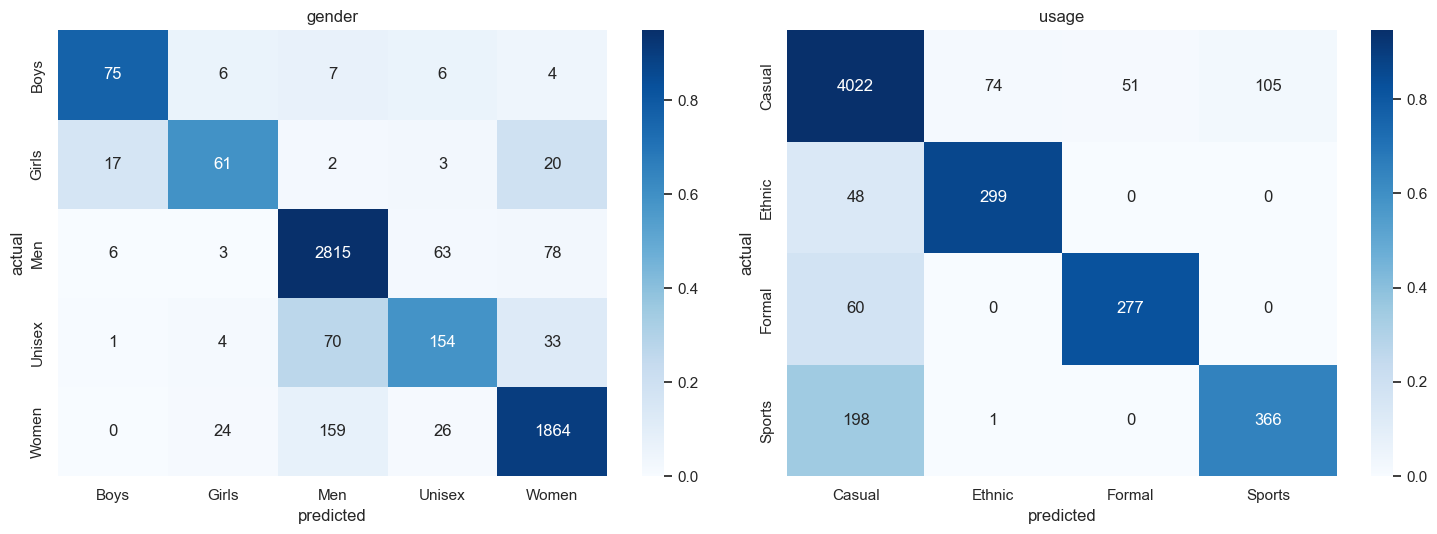

In [38]:
# ============================================
# CELL 21 - Test results
# ============================================

test_predictions = predict(FINAL_MODEL, test_loader)
test_summary = summarise(test_predictions)

final = pd.DataFrame([
    {"target": target,
     "accuracy": round(test_summary[target]["accuracy"], 2),
     "macro-F1": round(test_summary[target]["macro_f1"], 2),
     "balanced accuracy": round(test_summary[target]["balanced_acc"], 2),
     "majority baseline": round(BASELINE[target]["accuracy"], 2),
     "gain": round(test_summary[target]["accuracy"] - BASELINE[target]["accuracy"], 2)}
    for target in CONFIG["targets"]])
display(final)
print(f"exact match (both attributes correct): {test_summary['exact_match']:.2f}%")

for target in CONFIG["targets"]:
    print("\n" + "=" * 58); print(target.upper()); print("=" * 58)
    print(classification_report(test_predictions[target]["true"],
                                test_predictions[target]["pred"],
                                target_names=class_names[target],
                                zero_division=0, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, target in zip(axes, CONFIG["targets"]):
    matrix = confusion_matrix(test_predictions[target]["true"],
                              test_predictions[target]["pred"])
    normalised = matrix / matrix.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(normalised, annot=matrix, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names[target], yticklabels=class_names[target])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title(target)
plt.tight_layout(); plt.show()

,target,probabilities,T,accuracy %,mean confidence %,ECE,reported 99%+,right when it does %
0,gender,as trained,1.000,90.33,98.559998,8.24,91.0,94.21
1,gender,temperature scaled,5.829,90.33,90.180000,1.23,51.1,99.54
2,usage,as trained,1.000,90.24,99.040001,8.81,93.2,93.01
3,usage,temperature scaled,5.943,90.24,91.059998,1.35,32.1,98.75


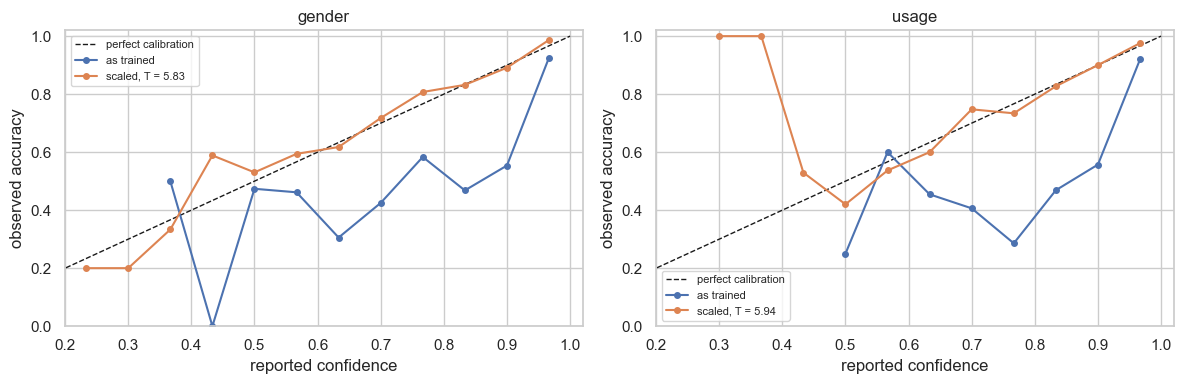

gender  T = 5.83 | ECE  8.24 ->  1.23 | mean confidence 98.6% -> 90.2%, against 90.3% accuracy
usage   T = 5.94 | ECE  8.81 ->  1.35 | mean confidence 99.0% -> 91.1%, against 90.2% accuracy

A temperature above one says the model was overconfident and the scaling has widened
its distributions; below one, the reverse. Accuracy is identical in both rows by
construction, so this buys nothing on any metric above and everything on what the
application can honestly say about its own certainty. It is fitted on catalogue
photographs, so it corrects catalogue confidence: a user's photograph, shot against a
real background, is outside the distribution the temperature was measured on.


In [39]:
# ============================================
# CELL 22 - Confidence calibration
# ============================================

# Accuracy says how often the model is right. Calibration asks something the metrics above
# cannot: when the model reports a probability beside a prediction, does that number mean
# anything? Trained to convergence with cross-entropy, a network of this kind drives its
# logits apart until the softmax saturates, and then reports near-certainty on almost
# everything - including what it gets wrong. No metric in this notebook detects that,
# because argmax does not care how sharp a distribution is. The application does: it prints
# the figure next to the prediction it shows a user, and it has no other way to say that a
# photograph is unlike anything it was trained on.
#
# Temperature scaling is the standard correction: one scalar per head, fitted on the
# validation split by minimising negative log-likelihood, dividing the logits before the
# softmax. Dividing every logit by the same positive number cannot reorder them, so no
# prediction and no metric above changes - the assertion below checks exactly that on the
# test partition. Only the reported probability moves.

def expected_calibration_error(confidence, correct, bins=15):
    """Mean gap between reported confidence and observed accuracy, weighted by occupancy."""
    edges = np.linspace(0, 1, bins + 1)
    error = 0.0
    for low, high in zip(edges[:-1], edges[1:]):
        inside = (confidence > low) & (confidence <= high)
        if inside.any():
            error += inside.mean() * abs(correct[inside].mean() - confidence[inside].mean())
    return error * 100


def fit_temperature(logits, labels, max_iter=100):
    """The scalar minimising validation NLL, optimised in log space so it stays positive."""
    logits_t = torch.tensor(np.asarray(logits), dtype=torch.float32)
    labels_t = torch.tensor(np.asarray(labels), dtype=torch.long)
    log_temperature = torch.zeros(1, requires_grad=True)
    optimiser = torch.optim.LBFGS([log_temperature], lr=0.1, max_iter=max_iter)

    def closure():
        optimiser.zero_grad()
        loss = F.cross_entropy(logits_t / log_temperature.exp(), labels_t)
        loss.backward()
        return loss

    optimiser.step(closure)
    return float(log_temperature.exp().item())


# Fitted on validation and never on test. A temperature is a parameter like any other, and
# fitting it on the partition it is then reported on would be the same mistake as tuning
# anything else there.
validation_final = predict(FINAL_MODEL, val_loader)
TEMPERATURE = {target: round(fit_temperature(validation_final[target]["logit"],
                                             validation_final[target]["true"]), 4)
               for target in CONFIG["targets"]}

calibration_rows = []
for target in CONFIG["targets"]:
    logits = torch.tensor(test_predictions[target]["logit"], dtype=torch.float32)
    correct = (test_predictions[target]["pred"]
               == test_predictions[target]["true"]).astype(float)
    for label, temperature in [("as trained", 1.0),
                               ("temperature scaled", TEMPERATURE[target])]:
        probabilities = F.softmax(logits / temperature, dim=1).numpy()
        assert (probabilities.argmax(1) == test_predictions[target]["pred"]).all(), \
            "scaling reordered a prediction, which a positive divisor cannot do"
        confidence = probabilities.max(1)
        confident = confidence >= 0.99
        calibration_rows.append({
            "target": target, "probabilities": label, "T": round(temperature, 3),
            "accuracy %": round(correct.mean() * 100, 2),
            "mean confidence %": round(confidence.mean() * 100, 2),
            "ECE": round(expected_calibration_error(confidence, correct), 2),
            "reported 99%+ ": round(confident.mean() * 100, 1),
            "right when it does %": round(correct[confident].mean() * 100, 2)
                                    if confident.any() else np.nan})

calibration = pd.DataFrame(calibration_rows)
display(calibration)

# Reliability: reported confidence against the accuracy actually observed at that
# confidence. A perfectly calibrated model sits on the diagonal; a curve below it is a
# model claiming more than it delivers.
edges = np.linspace(0, 1, 16)
centres = (edges[:-1] + edges[1:]) / 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, target in zip(axes, CONFIG["targets"]):
    logits = torch.tensor(test_predictions[target]["logit"], dtype=torch.float32)
    correct = (test_predictions[target]["pred"]
               == test_predictions[target]["true"]).astype(float)
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
    for label, temperature in [("as trained", 1.0),
                               (f"scaled, T = {TEMPERATURE[target]:.2f}",
                                TEMPERATURE[target])]:
        confidence = F.softmax(logits / temperature, dim=1).numpy().max(1)
        observed = [correct[(confidence > low) & (confidence <= high)].mean()
                    if ((confidence > low) & (confidence <= high)).any() else np.nan
                    for low, high in zip(edges[:-1], edges[1:])]
        ax.plot(centres, observed, marker="o", ms=4, label=label)
    ax.set_xlabel("reported confidence"); ax.set_ylabel("observed accuracy")
    ax.set_title(target); ax.legend(fontsize=8)
    ax.set_xlim(0.2, 1.02); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

as_trained = calibration[calibration["probabilities"] == "as trained"].set_index("target")
scaled = calibration[calibration["probabilities"] == "temperature scaled"].set_index("target")
for target in CONFIG["targets"]:
    print(f"{target:7s} T = {TEMPERATURE[target]:.2f} | "
          f"ECE {as_trained.loc[target, 'ECE']:5.2f} -> {scaled.loc[target, 'ECE']:5.2f} | "
          f"mean confidence {as_trained.loc[target, 'mean confidence %']:.1f}% -> "
          f"{scaled.loc[target, 'mean confidence %']:.1f}%, against "
          f"{as_trained.loc[target, 'accuracy %']:.1f}% accuracy")

print("\nA temperature above one says the model was overconfident and the scaling has widened")
print("its distributions; below one, the reverse. Accuracy is identical in both rows by")
print("construction, so this buys nothing on any metric above and everything on what the")
print("application can honestly say about its own certainty. It is fitted on catalogue")
print("photographs, so it corrects catalogue confidence: a user's photograph, shot against a")
print("real background, is outside the distribution the temperature was measured on.")

calibration.to_csv(ARTIFACT_DIR / "calibration.csv", index=False)


,items,gender %,usage %
masterCategory,,,
Sporting Goods,3,66.7,66.7
Personal Care,135,74.1,100.0
Accessories,1420,85.5,89.9
Footwear,1219,88.2,90.0
Free Items,11,90.9,100.0
Apparel,2713,94.7,90.0


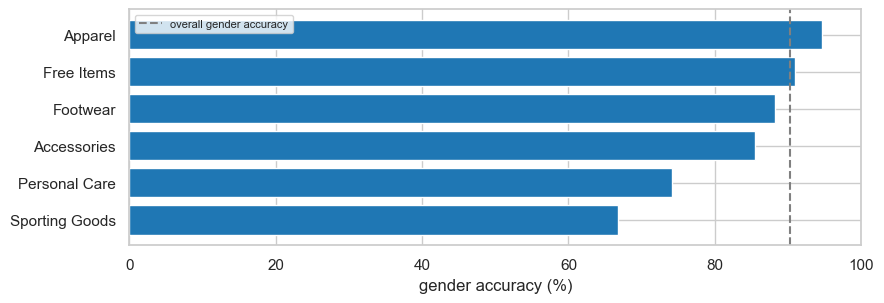

,items,gender %,train examples
group,,,
cosmetics,127,72.4,58
fragrance and other,8,100.0,640


Predicted gender for fragrance, deodorant and gift sets:


gender_pred,Women
gender_label,
Women,8


,share of gender errors %
masterCategory,
Accessories,38.7
Apparel,27.3
Footwear,27.1
Personal Care,6.6
Sporting Goods,0.2
Free Items,0.2


Gender accuracy ranges from 74.1% on Personal Care to 94.7% on Apparel.
The largest single source of error is Accessories, at 38.7% of all gender errors
from 1,420 test items. Personal Care has the lowest rate but contributes
only 6.6%, being 135 items of 5,501.

Accuracy tracks how much of the gender signal is carried by shape. A garment's cut differs
between the men's and women's ranges; a bottle, a watch or a bag frequently does not.
Resolution does not resolve it: the same table at 120x160 put Accessories at 85.2%,
against 85.5% here. The limit is what the photograph shows, not how finely it shows it.


In [40]:
# ============================================
# CELL 23 - Where the errors are
# ============================================

# Aggregate accuracy hides which kinds of item the model fails on. Every test
# prediction is joined back to its catalogue category, so the failures can be
# attributed rather than only counted.

analysis = test_df.copy()
for target in CONFIG["targets"]:
    analysis[target + "_pred"] = [class_names[target][i]
                                  for i in test_predictions[target]["pred"]]

gender_hit = analysis["gender_label"] == analysis["gender_pred"]
usage_hit = analysis["usage_label"] == analysis["usage_pred"]

by_category = pd.DataFrame({
    "items": analysis.groupby("masterCategory").size(),
    "gender %": (gender_hit.groupby(analysis["masterCategory"]).mean() * 100).round(1),
    "usage %": (usage_hit.groupby(analysis["masterCategory"]).mean() * 100).round(1),
}).sort_values("gender %")
display(by_category)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(by_category.index, by_category["gender %"], color="tab:blue")
ax.axvline(test_summary["gender"]["accuracy"], ls="--", color="grey",
           label="overall gender accuracy")
ax.set_xlabel("gender accuracy (%)"); ax.set_xlim(0, 100); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Personal Care contains two visually distinct populations that carry opposite
# gender priors, so it is split rather than reported as one figure.
COSMETICS = {"Lips", "Nails", "Eyes", "Makeup"}
CARE_GROUPS = ["cosmetics", "fragrance and other"]
care = analysis[analysis["masterCategory"] == "Personal Care"].copy()
# A categorical keeps both rows in the table even when the test partition happens to
# contain none of one group, so the counts below always line up with it.
care["group"] = pd.Categorical(
    np.where(care["subCategory"].isin(COSMETICS), *CARE_GROUPS[::-1]),
    categories=CARE_GROUPS)
care_hit = care["gender_label"] == care["gender_pred"]
display(pd.DataFrame({
    "items": care.groupby("group", observed=False).size(),
    "gender %": (care_hit.groupby(care["group"], observed=False).mean() * 100).round(1),
    "train examples": [int((train_df["subCategory"].isin(COSMETICS)).sum()),
                       int(((train_df["masterCategory"] == "Personal Care") &
                            (~train_df["subCategory"].isin(COSMETICS))).sum())]}))

fragrance = care[care["group"] == "fragrance and other"]
print("Predicted gender for fragrance, deodorant and gift sets:")
if len(fragrance):
    display(pd.crosstab(fragrance["gender_label"], fragrance["gender_pred"]))
else:
    print("  none in the test partition")

# Where the gender errors actually are, as a share of all of them.
error_share = (analysis.loc[~gender_hit, "masterCategory"]
               .value_counts(normalize=True) * 100).round(1)
error_share.name = "share of gender errors %"
display(error_share.to_frame())

substantial = by_category[by_category["items"] >= 50]
worst, best = substantial.index[0], substantial.index[-1]
largest = error_share.index[0]
print(f"Gender accuracy ranges from {substantial.loc[worst, 'gender %']:.1f}% on {worst} "
      f"to {substantial.loc[best, 'gender %']:.1f}% on {best}.")
print(f"The largest single source of error is {largest}, at {error_share.iloc[0]:.1f}% of all "
      f"gender errors\nfrom {int(by_category.loc[largest, 'items']):,} test items. "
      f"{worst} has the lowest rate but contributes\nonly {error_share.get(worst, 0.0):.1f}%, "
      f"being {int(by_category.loc[worst, 'items'])} items of {len(analysis):,}.")
print("\nAccuracy tracks how much of the gender signal is carried by shape. A garment's cut "
      "differs\nbetween the men's and women's ranges; a bottle, a watch or a bag frequently does "
      "not.\nResolution does not resolve it: the same table at 120x160 put Accessories at "
      "85.2%,\nagainst 85.5% here. The limit is what the photograph shows, not how finely it "
      "shows it.")

by_category.to_csv(ARTIFACT_DIR / "error_analysis.csv")


In [41]:
# ============================================
# CELL 24 - The ceiling on Sports
# ============================================

# `Sports` is the weakest class in the notebook, and a weakness is worth separating into the
# part a better model would fix and the part the data will not give up. The failure is
# one-directional, which is the first clue: almost everything missed is called `Casual`.

sports_missed = analysis[(analysis["usage_label"] == "Sports")
                         & (analysis["usage_pred"] != "Sports")]
print(f"Sports items in the test partition: {(analysis['usage_label'] == 'Sports').sum()}, "
      f"of which {len(sports_missed)} are missed")
display(sports_missed["usage_pred"].value_counts().to_frame("called instead"))

# Which garments they are, beside the way training labels that same garment.
top_types = sports_missed["articleType"].value_counts().head(6)
subset = train_df[train_df["articleType"].isin(top_types.index)]
display(pd.concat([top_types.rename("missed in test"),
                   pd.crosstab(subset["articleType"], subset["usage_label"])],
                  axis=1).fillna(0).astype(int))

# The decisive test. `articleType` is a catalogue field this network never sees. Predicting
# usage from it alone - each garment type's majority usage - is an oracle that knows exactly
# what the item is without ever looking at it. If `Sports` were recoverable from knowing the
# category, that oracle would recover it.
majority_usage = train_df.groupby("articleType")["usage_label"].agg(
    lambda s: s.value_counts().idxmax())
oracle = analysis["articleType"].map(majority_usage).fillna("Casual")
truth = analysis["usage_label"]
is_sports = truth == "Sports"

ceiling = pd.DataFrame([
    {"predictor": "articleType alone (an oracle)",
     "accuracy": (oracle == truth).mean() * 100,
     "macro-F1": f1_score(truth, oracle, average="macro", zero_division=0) * 100,
     "Sports recall": (oracle[is_sports] == "Sports").mean() * 100},
    {"predictor": "this network, from the image",
     "accuracy": (analysis["usage_pred"] == truth).mean() * 100,
     "macro-F1": f1_score(truth, analysis["usage_pred"], average="macro",
                          zero_division=0) * 100,
     "Sports recall": (analysis.loc[is_sports, "usage_pred"] == "Sports").mean() * 100},
]).round(2)
display(ceiling)

gap = ceiling.loc[1, "Sports recall"] - ceiling.loc[0, "Sports recall"]
print(f"Knowing exactly what the garment is recovers {abs(gap):.1f} points "
      f"{'less' if gap > 0 else 'more'} of Sports than the image does.")
print("\nThe attribute records what an item was sold for, not what it looks like. A sports\n"
      "t-shirt is a t-shirt: training files 4,169 t-shirts as Casual against 679 as Sports,\n"
      "and no amount of looking at one separates them. Recall on the class can still be bought\n"
      "at prediction time, by biasing the decision toward it or by training on a rebalanced\n"
      "sampler, but precision pays for it at close to one for one and the F1 barely moves -\n"
      "the signature of a fixed boundary being slid along rather than improved. Cell 20 records\n"
      "what happened when that trade was deployed and measured.")

ceiling.to_csv(ARTIFACT_DIR / "sports_ceiling.csv", index=False)


Sports items in the test partition: 565, of which 199 are missed


,called instead
usage_pred,
Casual,198
Ethnic,1


,missed in test,Casual,Formal,Sports
articleType,,,,
Tshirts,62,4169,1,679
Sports Shoes,60,26,0,1396
Socks,14,332,32,73
Shorts,10,239,0,136
Track Pants,7,68,0,142
Backpacks,7,453,0,54


,predictor,accuracy,macro-F1,Sports recall
0,articleType alone (an oracle),88.98,75.91,54.87
1,"this network, from the image",90.24,82.66,64.78


Knowing exactly what the garment is recovers 9.9 points less of Sports than the image does.

The attribute records what an item was sold for, not what it looks like. A sports
t-shirt is a t-shirt: training files 4,169 t-shirts as Casual against 679 as Sports,
and no amount of looking at one separates them. Recall on the class can still be bought
at prediction time, by biasing the decision toward it or by training on a rebalanced
sampler, but precision pays for it at close to one for one and the F1 barely moves -
the signature of a fixed boundary being slid along rather than improved. Cell 20 records
what happened when that trade was deployed and measured.


In [45]:
# ============================================
# CELL 25 - The ceiling on gender
# ============================================

# Accessories carry the largest share of the gender errors, and the usual reading is that
# a watch or a wallet looks much the same in the men's range as in the women's. Part of it
# is that. Most of it is not, and the difference decides whether anything can be done: one
# is a limit of the photograph, the other is a limit of the label.

gender_hit = analysis["gender_label"] == analysis["gender_pred"]
gender_errors = analysis[~gender_hit]
accessories = analysis[analysis["masterCategory"] == "Accessories"]
accessory_errors = gender_errors[gender_errors["masterCategory"] == "Accessories"]
print(f"gender errors: {len(gender_errors):,} of {len(analysis):,} test items")
print(f"  from Accessories: {len(accessory_errors)} of them "
      f"({len(accessory_errors) / len(gender_errors) * 100:.1f}% of every gender error), "
      f"out of {len(accessories):,} items")
display(pd.crosstab(accessory_errors["gender_label"], accessory_errors["gender_pred"]))

# The confusion is not mainly between the men's and the women's ranges.
involves_unisex = ((gender_errors["gender_label"] == "Unisex")
                   | (gender_errors["gender_pred"] == "Unisex"))
print(f"Errors that place or displace `Unisex`: {involves_unisex.sum()} of "
      f"{len(gender_errors)} ({involves_unisex.mean() * 100:.0f}%). The weak boundary is a third\n"
      f"label overlapping the other two, not the two being hard to tell apart.")

# What that boundary costs, as a bound rather than an estimate.
forgiven = (gender_hit | (analysis["gender_label"] == "Unisex")
            | (analysis["gender_pred"] == "Unisex"))
elsewhere = analysis[analysis["gender_label"] != "Unisex"]
display(pd.DataFrame([
    {"scored": "as reported", "gender accuracy": gender_hit.mean() * 100},
    {"scored": "forgiving every Unisex confusion", "gender accuracy": forgiven.mean() * 100},
    {"scored": "on non-Unisex items only",
     "gender accuracy": (elsewhere["gender_label"] == elsewhere["gender_pred"]).mean() * 100},
]).round(2))


# Whether the label is a property of the photograph at all, tested two ways.
#
# First: the catalogue files byte-identical photographs under different genders. These are
# the rows CELL 2 removes from training, and they are shown here because they are the
# cleanest possible demonstration that the attribute is not always in the pixels.
conflicts = pd.read_csv(PROCESSED_DIR / "conflicting_duplicates_120x160.csv")
disagreeing = conflicts.groupby("duplicate_hash")["gender"].nunique()
families = disagreeing[disagreeing > 1].index
print(f"Byte-identical photographs carrying different gender labels: {len(families)} families")
display(conflicts[conflicts["duplicate_hash"].isin(families)]
        .sort_values("duplicate_hash")[["id", "gender", "articleType", "productDisplayName"]]
        .head(8))

# Second: where the label comes from. `gender` tracks a word in the product title almost
# perfectly, and on accessories it tracks it exactly. That is the sense in which the
# attribute records how an item was listed rather than how it looks.
GENDER_WORDS = {"men": "Men", "man": "Men", "women": "Women", "woman": "Women",
                "boys": "Boys", "boy": "Boys", "girls": "Girls", "girl": "Girls",
                "unisex": "Unisex"}


def gender_stated_in(name):
    for token in str(name).lower().replace("-", " ").split():
        word = "".join(character for character in token if character.isalpha())
        if word in GENDER_WORDS:
            return GENDER_WORDS[word]
    return None


named = analysis.assign(name_gender=analysis["productDisplayName"].map(gender_stated_in))
named = named[named["name_gender"].notna()]
display(pd.DataFrame([
    {"rows": label, "n": len(frame),
     "the word in the title": (frame["name_gender"] == frame["gender_label"]).mean() * 100,
     "the network, same rows": (frame["gender_pred"] == frame["gender_label"]).mean() * 100}
    for label, frame in [("every test item stating a gender", named),
                         ("Accessories among them",
                          named[named["masterCategory"] == "Accessories"])]]).round(2))

print("The gender of an accessory is the word the seller put in the listing, and the photograph\n"
      "is a proxy for it: a good proxy for a dress, a poor one for a wallet. Some of these labels\n"
      "cannot be recovered from pixels at all, since one photograph carries two of them. Nor is\n"
      "resolution the constraint, which was measured: Accessories scored 85.2% at 120x160 against\n"
      f"{(accessories['gender_label'] == accessories['gender_pred']).mean() * 100:.1f}% here.")

pd.DataFrame([{"accessory_gender_accuracy":
               (accessories["gender_label"] == accessories["gender_pred"]).mean() * 100,
               "share_of_gender_errors": len(accessory_errors) / len(gender_errors) * 100,
               "errors_involving_unisex_pct": involves_unisex.mean() * 100,
               "accuracy_forgiving_unisex": forgiven.mean() * 100}]).round(2).to_csv(
    ARTIFACT_DIR / "gender_ceiling.csv", index=False)


gender errors: 532 of 5,501 test items
  from Accessories: 206 of them (38.7% of every gender error), out of 1,420 items


gender_pred,Boys,Girls,Men,Unisex,Women
gender_label,,,,,
Boys,0,0,0,0,1
Girls,0,0,0,0,3
Men,0,0,0,38,30
Unisex,1,1,27,0,25
Women,0,2,55,23,0


Errors that place or displace `Unisex`: 206 of 532 (39%). The weak boundary is a third
label overlapping the other two, not the two being hard to tell apart.


,scored,gender accuracy
0,as reported,90.33
1,forgiving every Unisex confusion,94.07
2,on non-Unisex items only,91.91


Byte-identical photographs carrying different gender labels: 7 families


,id,gender,articleType,productDisplayName
39,8273,Men,Tshirts,Doodle Men Athletic 77 Dept Yellow tee Yellow Kidswear
40,8325,Boys,Tshirts,Doodle Boy's Athletic 77 Dept Yellow Teen Kidswear
20,28167,Men,Sunglasses,Ray-Ban Men Aviator Gold Sunglasses
21,28186,Unisex,Sunglasses,Ray-Ban Unisex Aviator Gold Sunglasses
22,28188,Men,Sunglasses,Ray-Ban Men Aviator Gold Sunglasses
29,36762,Men,Watches,Maxima Men White Dial Watch
30,36771,Women,Watches,Maxima Women White Dial Watch
14,23793,Unisex,Casual Shoes,Converse Unisex Tongue Triple Color Black Casual Shoes


,rows,n,the word in the title,"the network, same rows"
0,every test item stating a gender,4933,98.8,90.19
1,Accessories among them,1393,100.0,85.79


The gender of an accessory is the word the seller put in the listing, and the photograph
is a proxy for it: a good proxy for a dress, a poor one for a wallet. Some of these labels
cannot be recovered from pixels at all, since one photograph carries two of them. Nor is
resolution the constraint, which was measured: Accessories scored 85.2% at 120x160 against
85.5% here.


In [42]:
# ============================================
# CELL 26 - Final architecture specification
# ============================================

settings = FINAL_MODEL.settings
shared_shape = flat_features(FINAL_MODEL.shared)[1]
branch_size, branch_shape = flat_features(
    nn.Sequential(FINAL_MODEL.shared, FINAL_MODEL.branches["gender"]))

specification = pd.DataFrame([
    ("Input", f"{CONFIG['channels']} x {CONFIG['image_height']} x {CONFIG['image_width']} RGB"),
    ("Reference design", "VGG-style: paired 3x3 convolutions per block, channels doubling"),
    ("Multi-task structure", "early branching - shared trunk, then one pathway per attribute"),
    ("Convolution kernel", "3 x 3, stride 1, padding 1 (all layers)"),
    ("Filters, shared trunk", " -> ".join(str(w) for w in settings["shared_widths"])),
    ("Filters, each branch", " -> ".join(str(w) for w in settings["branch_widths"])),
    ("Convolutions per block", "2, each followed by batch normalisation"),
    ("Activation", {"relu": "ReLU", "tanh": "tanh", "sigmoid": "sigmoid"}[settings["activation"]]),
    ("Normalisation", "BatchNorm2d after every convolution"),
    ("Pooling", f"{'max' if settings['pooling'] == 'max' else 'average'} pooling, 2 x 2, stride 2"),
    ("Shared trunk output", f"{shared_shape[0]} x {shared_shape[1]} x {shared_shape[2]}"),
    ("Branch output", f"{branch_shape[0]} x {branch_shape[1]} x {branch_shape[2]}"),
    ("Classifier input", "flatten" if settings["head"] == "flatten"
     else "global average pooling"),
    ("Flattened size", f"{branch_size}" if settings["head"] == "flatten"
     else f"{branch_shape[0]} (one value per channel)"),
    ("Classifier", f"Dropout({settings['dropout']}) -> Linear(., {settings['hidden']}) "
     f"-> ReLU -> Dropout({settings['dropout']}) -> Linear({settings['hidden']}, classes)"),
    ("Output", f"gender {NUM_CLASSES['gender']} scores, usage {NUM_CLASSES['usage']} scores; "
     "softmax applied at prediction time"),
    ("Loss", "cross-entropy per attribute, summed with equal weight"),
    ("Optimiser", f"AdamW, lr {CONFIG['learning_rate']}, weight decay {CONFIG['weight_decay']}"),
    ("Learning rate schedule", "halved after 3 epochs without validation improvement"),
    ("Regularisation", f"dropout {settings['dropout']}, weight decay, batch norm, early stopping"),
    ("Class imbalance", {"base": "none applied",
                         "balanced": "balanced batch sampling (equal classes per batch)",
                         "balanced_aug": "balanced sampling with flip, scale and "
                                         "translation jitter",
                         "class_weighted": "per-head inverse-frequency class weights in "
                                           "the loss"}.get(FINAL_NAME, FINAL_NAME)),
    ("Confidence calibration", "temperature scaling, " + ", ".join(
        f"{target} T={TEMPERATURE[target]:.2f}" for target in CONFIG["targets"])),
    ("Training seed", f"{BEST_SEED}" + (f" (best of {len(SEEDS)} repeated runs)"
                                        if len(SEEDS) > 1 else " (one run per configuration)")),
    ("Selection rule", f"highest validation mean macro-F1; ties within "
     f"+-{EFFECTIVE_NOISE:.2f} broken on usage macro-F1"),
    ("Configuration the rule retained", RULE_NAME),
    ("Configuration deployed", f"{FINAL_NAME}" + ("" if FINAL_NAME == RULE_NAME
                                                  else f" - {DEPLOY_REASON}")),
    ("Total parameters", f"{count_parameters(FINAL_MODEL):,}"),
], columns=["component", "setting"])

pd.set_option("display.max_colwidth", 90)
display(specification)
specification.to_csv(ARTIFACT_DIR / "final_architecture.csv", index=False)

,component,setting
0,Input,3 x 80 x 60 RGB
1,Reference design,"VGG-style: paired 3x3 convolutions per block, channels doubling"
2,Multi-task structure,"early branching - shared trunk, then one pathway per attribute"
3,Convolution kernel,"3 x 3, stride 1, padding 1 (all layers)"
4,"Filters, shared trunk",32 -> 64
5,"Filters, each branch",128 -> 256
6,Convolutions per block,"2, each followed by batch normalisation"
7,Activation,ReLU
8,Normalisation,BatchNorm2d after every convolution
9,Pooling,"max pooling, 2 x 2, stride 2"


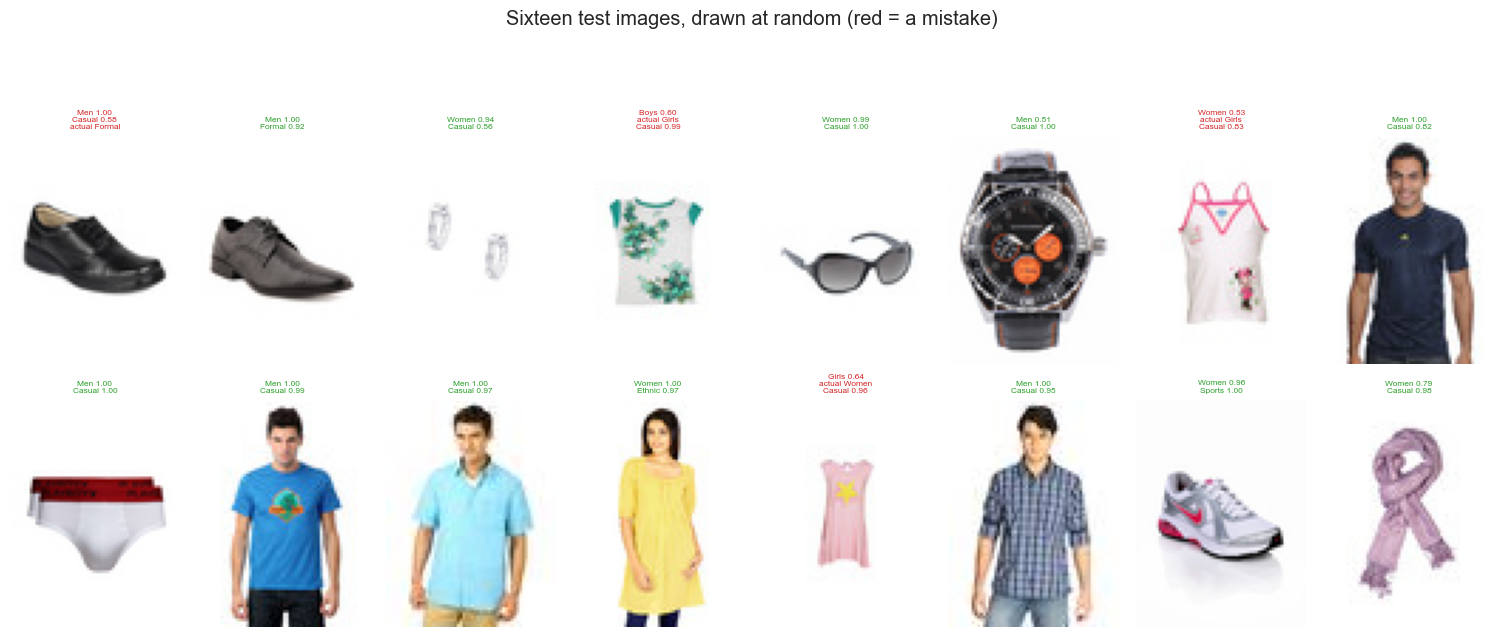

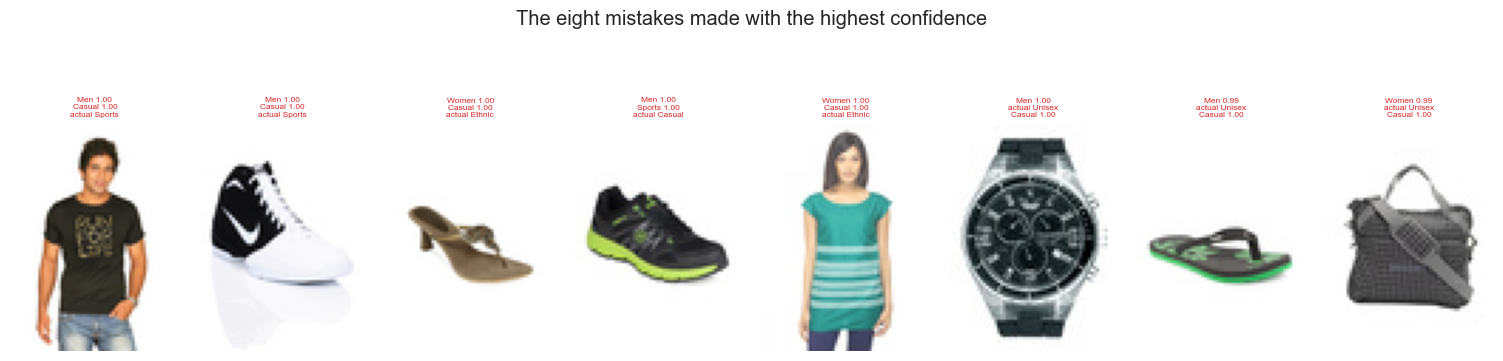

In [43]:
# ============================================
# CELL 27 - Predictions on sample images
# ============================================

# Two panels. A random draw shows typical behaviour; the highest-confidence errors
# show the failure mode. The random draw is sixteen images rather than a handful,
# because at this accuracy a smaller sample is dominated by which items it happened
# to contain.

def prediction_panel(frame, title, columns=8):
    rows = int(np.ceil(len(frame) / columns))
    images, _, _ = next(iter(DataLoader(FashionDataset(frame), batch_size=len(frame))))
    FINAL_MODEL.eval()
    with torch.no_grad():
        logits = FINAL_MODEL(images.to(DEVICE))

    height = 3.0 * rows + 0.8          # reserve space for the figure title
    fig, axes = plt.subplots(rows, columns, figsize=(1.9 * columns, height))
    flat_axes = np.ravel(np.array(axes, dtype=object))
    for position, (ax, (_, row)) in enumerate(zip(flat_axes, frame.iterrows())):
        ax.imshow(np.asarray(IMAGES[row["pos"]])); ax.axis("off")
        lines, correct = [], True
        for target in CONFIG["targets"]:
            probabilities = F.softmax(logits[target][position].float()
                                      / TEMPERATURE[target], dim=0).cpu().numpy()
            index = int(probabilities.argmax())
            hit = class_names[target][index] == row[target + "_label"]
            correct &= hit
            actual = "" if hit else f"\nactual {row[target + '_label']}"
            lines.append(f"{class_names[target][index]} {probabilities[index]:.2f}{actual}")
        ax.set_title("\n".join(lines), fontsize=6,
                     color="tab:green" if correct else "tab:red")
    for ax in flat_axes[len(frame):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.55 / height))
    plt.show()


set_seed()
prediction_panel(test_df.sample(16, random_state=RANDOM_STATE),
                 "Sixteen test images, drawn at random (red = a mistake)")

# The mistakes made at the highest probability: the cases the model is wrong about
# without any indication that it might be.
# Calibrated probabilities, so that "highest confidence" here means the same thing as the
# figure printed under each image. Scaling is monotonic within a head, so this changes the
# ordering only where the two heads' temperatures differ.
calibrated = {target: F.softmax(torch.tensor(test_predictions[target]["logit"])
                                / TEMPERATURE[target], dim=1).numpy()
              for target in CONFIG["targets"]}
confidence = np.minimum(calibrated["gender"].max(axis=1), calibrated["usage"].max(axis=1))
mistaken = ((test_predictions["gender"]["pred"] != test_predictions["gender"]["true"]) |
            (test_predictions["usage"]["pred"] != test_predictions["usage"]["true"]))
ranked = np.argsort(-np.where(mistaken, confidence, -1.0))[:8]
prediction_panel(test_df.iloc[ranked],
                 "The eight mistakes made with the highest confidence")


In [44]:
# ============================================
# CELL 28 - Save
# ============================================

torch.save({
    "state_dict": FINAL_MODEL.state_dict(),
    "model_name": FINAL_NAME,
    # Which configuration the ranking retained, kept beside the one actually shipped so a
    # reader of the checkpoint can see that the two differ and why.
    "selected_by_rule": RULE_NAME,
    "deployment_reason": SELECTION_REASON,
    "architecture": FINAL_MODEL.settings,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    # Ones tell the serving code to take the highest probability directly. These are the
    # threshold-adjustment multipliers, evaluated in an earlier version of this notebook
    # and not adopted; they are unrelated to the class weights used in the loss, which
    # shape training and leave nothing to apply at prediction time.
    "class_weights": {t: np.ones(NUM_CLASSES[t]).tolist() for t in CONFIG["targets"]},
    "thresholds_applied": False,
    # One divisor per head, applied to the logits before the softmax so that the number the
    # application displays beside a prediction matches how often that prediction is right.
    # Monotonic, so it changes no prediction and none of the metrics above.
    "temperature": TEMPERATURE,
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "test_metrics": {t: test_summary[t] for t in CONFIG["targets"]},
}, ARTIFACT_DIR / "task3_cnn_model.pt")

selection.to_csv(ARTIFACT_DIR / "model_selection.csv", index=False)
final.to_csv(ARTIFACT_DIR / "final_test_metrics.csv", index=False)

summary = {
    "final_model": FINAL_NAME,
    "selected_by_rule": RULE_NAME,
    "parameters": count_parameters(FINAL_MODEL),
    "noise_floor": round(NOISE_FLOOR, 3),
    "test_gender_accuracy": round(test_summary["gender"]["accuracy"], 2),
    "test_gender_macro_f1": round(test_summary["gender"]["macro_f1"], 2),
    "test_usage_accuracy": round(test_summary["usage"]["accuracy"], 2),
    "test_usage_macro_f1": round(test_summary["usage"]["macro_f1"], 2),
    "test_exact_match": round(test_summary["exact_match"], 2),
    "temperature": TEMPERATURE,
    "baseline_gender_accuracy": round(BASELINE["gender"]["accuracy"], 2),
    "baseline_usage_accuracy": round(BASELINE["usage"]["accuracy"], 2),
}
with open(ARTIFACT_DIR / "task3_cnn_summary.json", "w") as handle:
    json.dump(summary, handle, indent=2)

print(json.dumps(summary, indent=2))
print("\nsaved to", ARTIFACT_DIR)
for path in sorted(ARTIFACT_DIR.iterdir()):
    print("  ", path.name)

{
  "final_model": "base",
  "selected_by_rule": "base",
  "parameters": 4249577,
  "noise_floor": 0.674,
  "test_gender_accuracy": 90.33,
  "test_gender_macro_f1": 76.37,
  "test_usage_accuracy": 90.24,
  "test_usage_macro_f1": 82.66,
  "test_exact_match": 81.59,
  "temperature": {
    "gender": 5.8289,
    "usage": 5.9429
  },
  "baseline_gender_accuracy": 54.2,
  "baseline_usage_accuracy": 77.11
}

saved to c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3
   calibration.csv
   error_analysis.csv
   final_architecture.csv
   final_test_metrics.csv
   imbalance_comparison.csv
   model_selection.csv
   sampler_gender_exposure.csv
   seed_repeats.csv
   sports_ceiling.csv
   task3_cnn_model.pt
   task3_cnn_summary.json
   weak_class_recall.csv


## Summary

A VGG-style convolutional network with early task branching predicts both attributes from a
60×80 image. The design choices (3×3 kernels, doubling filter counts, ReLU, max pooling and a
flatten-then-dense classifier) are argued from first principles in Part 2 and taken as given.
The retained model has 4.2M parameters and reaches **90.33% accuracy and 76.37 macro-F1 on
gender, 90.24% and 82.66 on usage, and 81.59% exact match** on the held-out partition, against
majority-class baselines of 54.20% and 77.11%.

Resolution was measured rather than assumed. The same pipeline trained at 120×160, with a fifth
convolutional block and three times the parameters, returned every test metric within 0.2 of the
figures at this resolution. Four times the pixels bought nothing, so the notebook runs at the
resolution the images are supplied at and spends the saved time on repeated runs instead, which
is what the comparison, rather than the model, was short of.

Part 5 examined class imbalance. The diagnosis in Cell 12 establishes whether the network is
predicting `Casual` indiscriminately, the mechanism the corrections are designed to counter,
before any correction is applied. Three are then measured against it: balanced batch sampling,
balanced sampling with mild augmentation, and per-head class weights in the loss. **None of the
three was retained.** Balanced sampling cost 1.90 macro-F1 on gender at the shared seed, the
cost the exposure table in Cell 17 predicts: the minority `usage` classes are dominated by the
majority genders, so equalising one attribute makes the rare classes of the other two to three
times rarer. Augmentation raised recall on the weakest `usage` class from 68.9% to 82.5% and
returned no macro-F1 for it. Class weighting, which leaves the sampling alone and so avoids that
trade entirely, was the only correction to improve gender at all, and lifted `Unisex` recall from
60.5% to 72.1% and `Sports` from 68.9% to 73.0%, but the gain did not survive into macro-F1,
because the recall it buys on a rare class is paid for in precision on that class. Each of the
three is a measured negative result rather than a discarded experiment.

`Sports` is the weakest class that remains, at 0.648 recall, and Cell 24 separates how much
of that a better model could recover. Predicting `usage` from `articleType` alone, an oracle
that knows exactly what the garment is and which the network never sees, reaches 54.9% recall on
`Sports` against the network's 64.8%. Knowing the category recovers less than looking at the
photograph does, because the attribute records what an item was sold for rather than what it
looks like: training files 4,169 t-shirts as `Casual` against 679 as `Sports`. The recall can
still be bought, either by biasing the decision at prediction time or by training on a
rebalanced sampler, and Cell 20 records what happened when the second of those was deployed and
measured on the test partition. It raised `Sports` recall from 64.8% to 83.4% and dropped its
precision from 77.7% to 63.3%, moving F1 by 1.3; the same trade cost 2.69 gender macro-F1 and
2.70 exact match, because the sampler equalises one attribute through a trunk the other shares.
The deployment was reverted and the reasoning kept, since a correction paid for in an attribute
it was never aimed at is evidence that the aggregate metric was measuring something real.

The other concentration of error is `gender` on accessories, and Cell 25 gives it the same
treatment. Accessories supply 38.7% of every gender error, but the confusion is not mainly
between the men's range and the women's: 39% of all gender errors place or displace `Unisex`, a
third label overlapping the other two, and forgiving those confusions alone would move gender
accuracy from 90.33% to 94.07%. The label is not always a property of the photograph. Seven
families of byte-identical images carry different genders, one Ray-Ban aviator appearing as both
`Men` and `Unisex`, and a word in the product title matches the label on 98.8% of test rows and
on 100% of accessories. What an accessory's gender records is how the seller listed it, and the
photograph is a proxy for that: a good one for a dress, a poor one for a wallet. Resolution does
not address it, and that was measured rather than assumed.

Selection ranks on validation mean macro-F1 against a threshold with two terms: the sampling
error of the validation set, ±0.67, and the run-to-run variance of identical code, measured
across three seeds per configuration at ±0.46. The larger governs, so the threshold is ±0.67.
Three of the four configurations fall inside it, no tie-break clears the same margin, and the
rule therefore falls through to the pipeline requiring the least machinery, which is the
uncorrected one. The measured spread matters: an earlier single-seed version of this notebook had
to carry ±1.17 over from a previous experiment, and that figure was 2.5 times the variance this
data actually shows, wide enough to have absorbed a real difference had one existed.

One qualifier bounds the comparison. Four of the twelve runs reached the 50-epoch cap while still
improving, so their scores are floors: two of `balanced_aug` and two of `class_weighted`. Every
run of `base` and of `balanced` stopped on patience instead. The truncation therefore works
against the challengers rather than against the retained configuration, which is the direction
that leaves the result standing, but the margin over `class_weighted`, 0.26 and already well
inside the threshold, is an upper bound rather than a measurement.

Part 6 also measures calibration, which accuracy does not capture. A network trained to
convergence with cross-entropy saturates its softmax and reports near-certainty on almost
everything, including what it gets wrong: as trained, this model reports a mean confidence of
98.6% on gender against 90.3% accuracy, and 99.0% on usage against 90.2%. One temperature per
head, fitted on the validation split, brings expected calibration error from 8.24 to 1.23 and
from 8.81 to 1.35. Because dividing every logit by the same positive number cannot reorder them,
no prediction and no metric above changes, as Cell 22 asserts, and only the reported
probability moves. It is fitted on catalogue photographs and corrects catalogue confidence; a
photograph taken against a real background remains outside the distribution it was measured on.
